# **FYS-STK3155 Project 1**: Numerical results

This notebook runs the experiments from the `scripts/part_*.py` files, makes the plots, and saves the figures and tables used in the report.

Before rerunning the notebook:
- Run `uv sync` in the terminal.
- Select the correct project kernel.


In [10]:
"""Tools used:
    - Copilot autocomplete
    - ChatGPT (October 2026)
"""
from pathlib import Path

import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import project1
from project1.utils import runge_function
from project1.utils.report import save_figure, save_latex_table

jax.config.update("jax_enable_x64", True)  # type: ignore

PROJECT_ROOT = Path(project1.__file__).resolve().parents[2]  # meh, but easiest way

### PLEASE SET THESE TO NONE if you do not want to save figures and tables
FIGURES_DIR = PROJECT_ROOT / "figures"
TABLES_DIR = PROJECT_ROOT / "report" / "tables"

if FIGURES_DIR is not None:
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
if TABLES_DIR is not None:
    TABLES_DIR.mkdir(parents=True, exist_ok=True)


In [11]:
# Plotting colours.
BLUE = "#0072B2"
RED = "#D55E00"
YELLOW = "#E69F00"
GREEN = "#009E73"
PURPLE = "#CC79A7"
GREY = "#777777"
BLACK = "#000000"

OLS_COLOR = BLUE
RIDGE_COLOR = RED
LASSO_COLOR = YELLOW

TRAIN_COLOR = GREY
TEST_COLOR = BLUE
BIAS_COLOR = RED
VARIANCE_COLOR = GREEN
ERROR_COLOR = BLACK

GD_COLOR = BLACK
MOMENTUM_COLOR = BLUE
ADAGRAD_COLOR = GREEN
RMSPROP_COLOR = PURPLE
ADAM_COLOR = RED

np.set_printoptions(precision=6, suppress=False)


## **Data used in Project 1**

We use Runge's function

$$f(x) = \frac{1}{1+25x^2}, \quad x \in [-1,1],$$

with Gaussian noise

$$y = f(x) + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0,\sigma^2).$$

For the main analysis, we use $N=100$ and $\sigma=0.1$. The same dataset and seed are used throughout the notebook so that the results are reproducible.

In [12]:
N = 100
NOISE = 0.1
SEED = 2026
MAX_DEGREE = 15
TEST_SIZE = 0.2
LAMBDAS = np.logspace(-4, 2, 20)

x, y = runge_function(n=N, noise=NOISE, seed=SEED)

print(f"n = {len(y)}, noise sigma = {NOISE}, lambda grid = {LAMBDAS[0]:.1e} ... {LAMBDAS[-1]:.1e}")


n = 100, noise sigma = 0.1, lambda grid = 1.0e-04 ... 1.0e+02


# **Part a)**: OLS


In [13]:
from project1.scripts import part_a

### Noise and sample-size sensitivity

First, we check how the OLS results change when the noise level or the number of data points is changed.

In [14]:
# main result: noise = 0.1, N = 100
result_a = part_a.run(x, y, max_degree=MAX_DEGREE, test_size=TEST_SIZE, seed=SEED)

# Vary the noise level while keeping N fixed.
noise_results = {
    0.1: result_a,
    0.3: part_a.run(
        *runge_function(n=N, noise=0.3, seed=SEED),
        max_degree=MAX_DEGREE,
        test_size=TEST_SIZE,
        seed=SEED,
    ),
    0.5: part_a.run(
        *runge_function(n=N, noise=0.5, seed=SEED),
        max_degree=MAX_DEGREE,
        test_size=TEST_SIZE,
        seed=SEED,
    ),
}

# Vary the sample size while keeping the noise fixed.
sample_results = {
    100: result_a,
    300: part_a.run(
        *runge_function(n=300, noise=NOISE, seed=SEED),
        max_degree=MAX_DEGREE,
        test_size=TEST_SIZE,
        seed=SEED,
    ),
    500: part_a.run(
        *runge_function(n=500, noise=NOISE, seed=SEED),
        max_degree=MAX_DEGREE,
        test_size=TEST_SIZE,
        seed=SEED,
    ),
}

sensitivity_rows = []
for sigma, result in noise_results.items():
    i = int(np.argmin(result["test_mse"]))
    sensitivity_rows.append(
        {
            "N": N,
            "$\\sigma$": sigma,
            "Best degree": int(result["degrees"][i]),
            "Train MSE": float(result["train_mse"][i]),
            "Test MSE": float(result["test_mse"][i]),
            "Test $R^2$": float(result["test_r2"][i]),
        }
    )

for n_value, result in sample_results.items():
    i = int(np.argmin(result["test_mse"]))
    sensitivity_rows.append(
        {
            "N": n_value,
            "$\\sigma$": NOISE,
            "Best degree": int(result["degrees"][i]),
            "Train MSE": float(result["train_mse"][i]),
            "Test MSE": float(result["test_mse"][i]),
            "Test $R^2$": float(result["test_r2"][i]),
        }
    )

sensitivity_table = pd.DataFrame(sensitivity_rows)
sensitivity_table


,N,$\sigma$,Best degree,Train MSE,Test MSE,Test $R^2$
0,100,0.1,12,0.014031,0.018943,0.847337
1,100,0.3,7,0.135449,0.110561,0.568581
2,100,0.5,7,0.359682,0.301086,0.352255
3,100,0.1,12,0.014031,0.018943,0.847337
4,300,0.1,13,0.011448,0.013670,0.784305
5,500,0.1,15,0.009648,0.014392,0.854119


In [15]:
save_latex_table(
    sensitivity_table,
    TABLES_DIR,
    "part_a_sensitivity.tex",
    "OLS sensitivity to noise level and sample size.",
    "ols-sensitivity",
)

Saved: /home/hmmorad/school/STK/fys-stk3155/project1/report/tables/part_a_sensitivity.tex
Use in main.tex: \input{tables/part_a_sensitivity.tex}


PosixPath('/home/hmmorad/school/STK/fys-stk3155/project1/report/tables/part_a_sensitivity.tex')

Runge's function with noise $\sigma=0.1$ and $N=100$, is used for the rest of the project.

Saved: /home/hmmorad/school/STK/fys-stk3155/project1/figures/part_a_ols_mse_r2.pdf


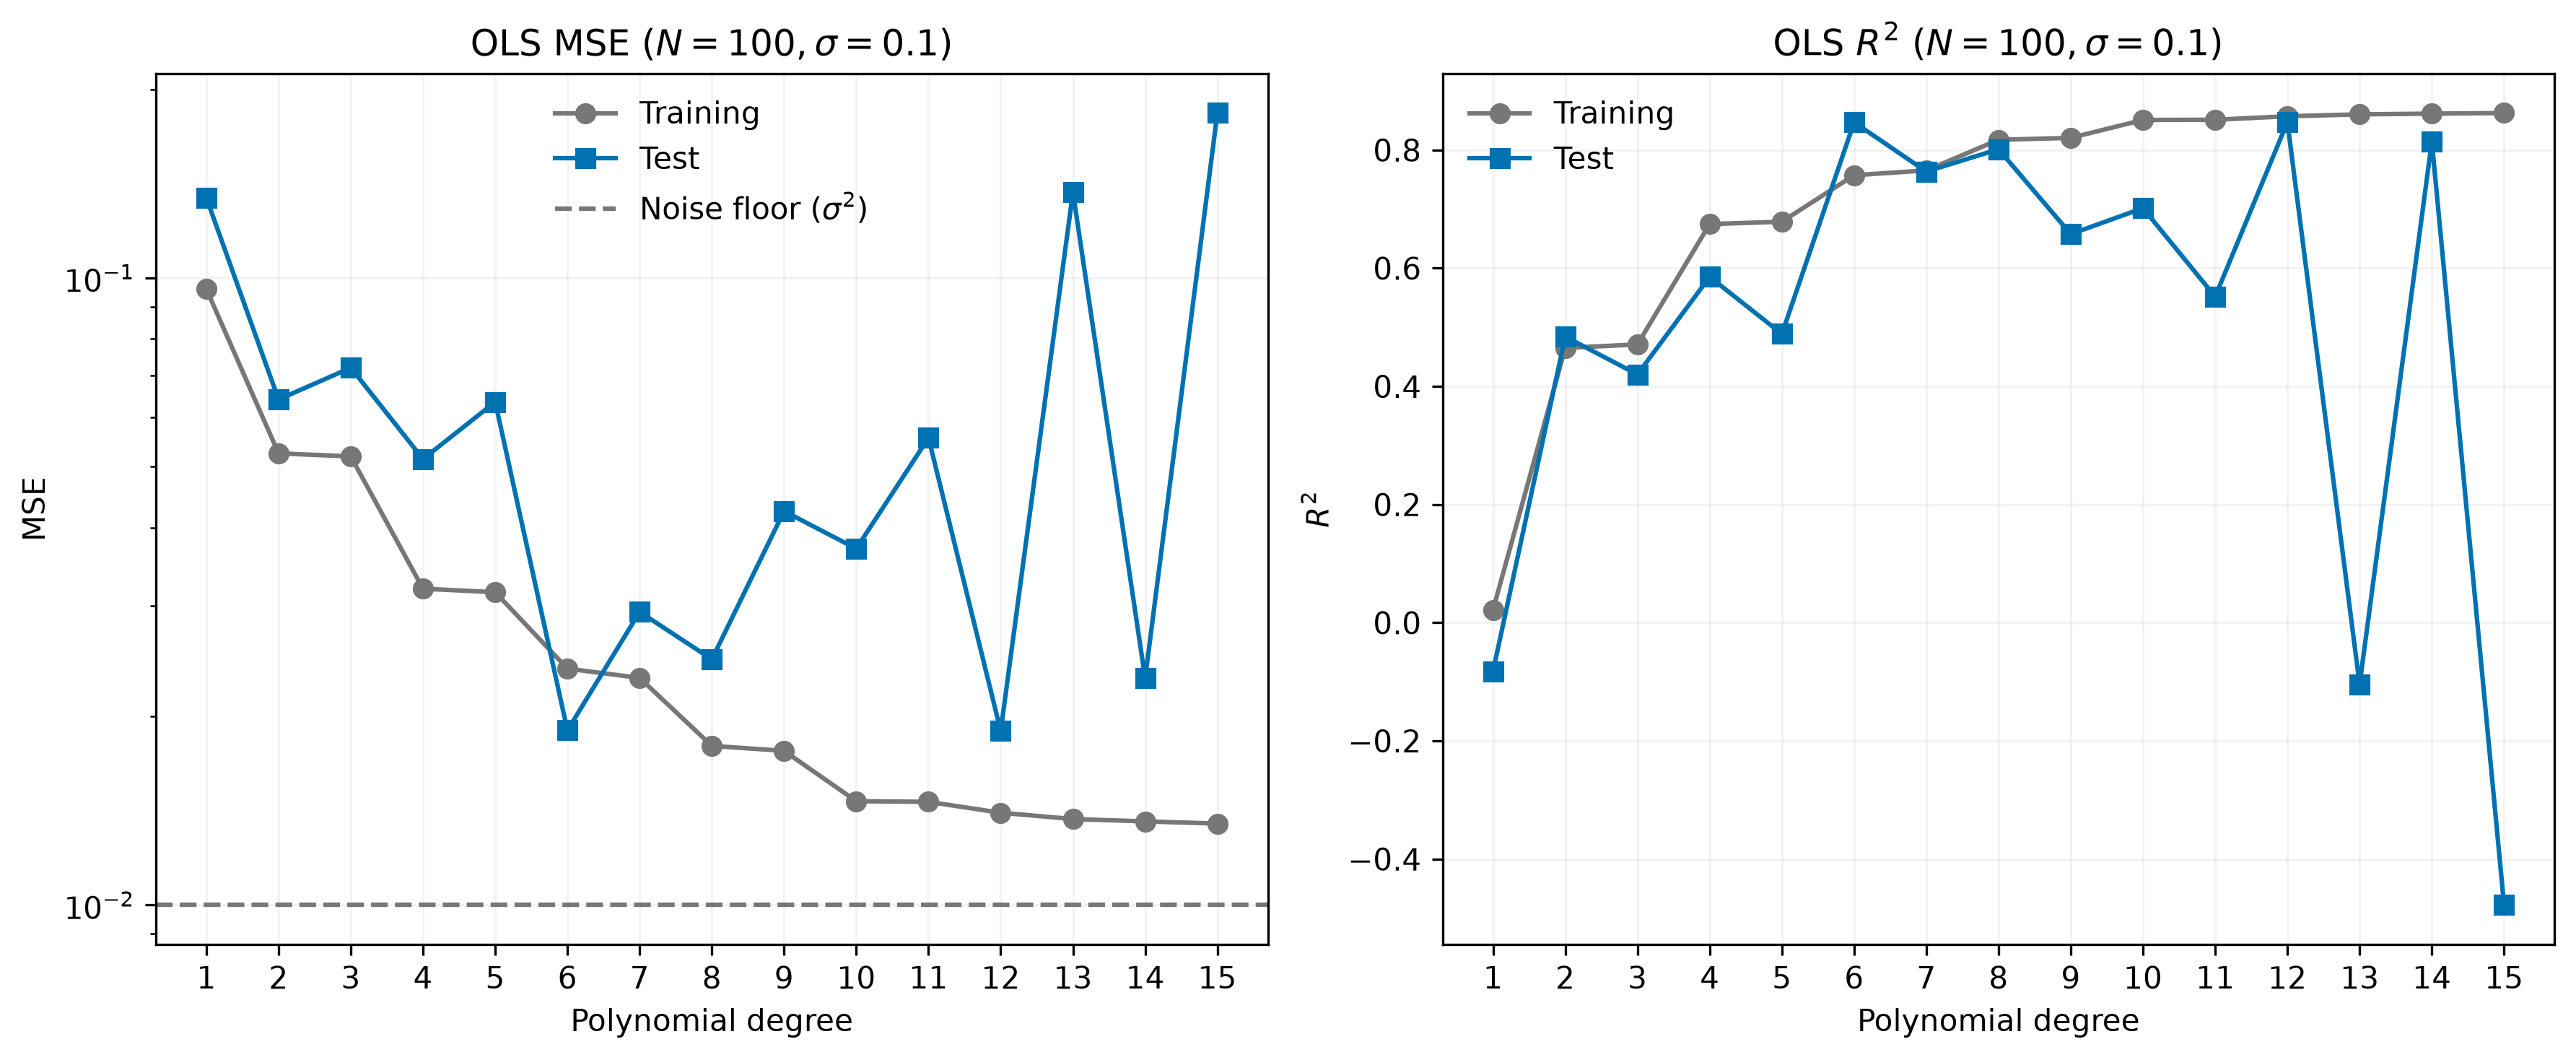

Best test $R^2$: 0.847 at degree 12


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(result_a["degrees"], result_a["train_mse"], "o-", color=TRAIN_COLOR, label="Training")
axes[0].plot(result_a["degrees"], result_a["test_mse"], "s-", color=TEST_COLOR, label="Test")
axes[0].axhline(NOISE**2, color=GREY, linestyle="--", label=r"Noise floor ($\sigma^2$)")
axes[0].set_title(r"OLS MSE ($N=100, \sigma=0.1$)")
axes[0].set_xlabel("Polynomial degree")
axes[0].set_ylabel("MSE")
axes[0].set_yscale("log")
axes[0].set_xticks(result_a["degrees"])
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.15)

axes[1].plot(result_a["degrees"], result_a["train_r2"], "o-", color=TRAIN_COLOR, label="Training")
axes[1].plot(result_a["degrees"], result_a["test_r2"], "s-", color=TEST_COLOR, label="Test")
axes[1].set_title(r"OLS $R^2$ ($N=100, \sigma=0.1$)")
axes[1].set_xlabel("Polynomial degree")
axes[1].set_ylabel(r"$R^2$")
axes[1].set_xticks(result_a["degrees"])
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.15)

fig.tight_layout()
path_a_mse = save_figure(fig, FIGURES_DIR, "part_a_ols_mse_r2.pdf")
path_a_r2 = path_a_mse
plt.show()

best_r2 = np.argmax(result_a["test_r2"])
print(
    f"Best test $R^2$: {result_a['test_r2'][best_r2]:.3f} at degree {result_a['degrees'][best_r2]}"
)

### Fitted coefficients

Next, we look at how the fitted coefficients change as the polynomial degree increases.

Saved: /home/hmmorad/school/STK/fys-stk3155/project1/figures/part_a_ols_theta.pdf


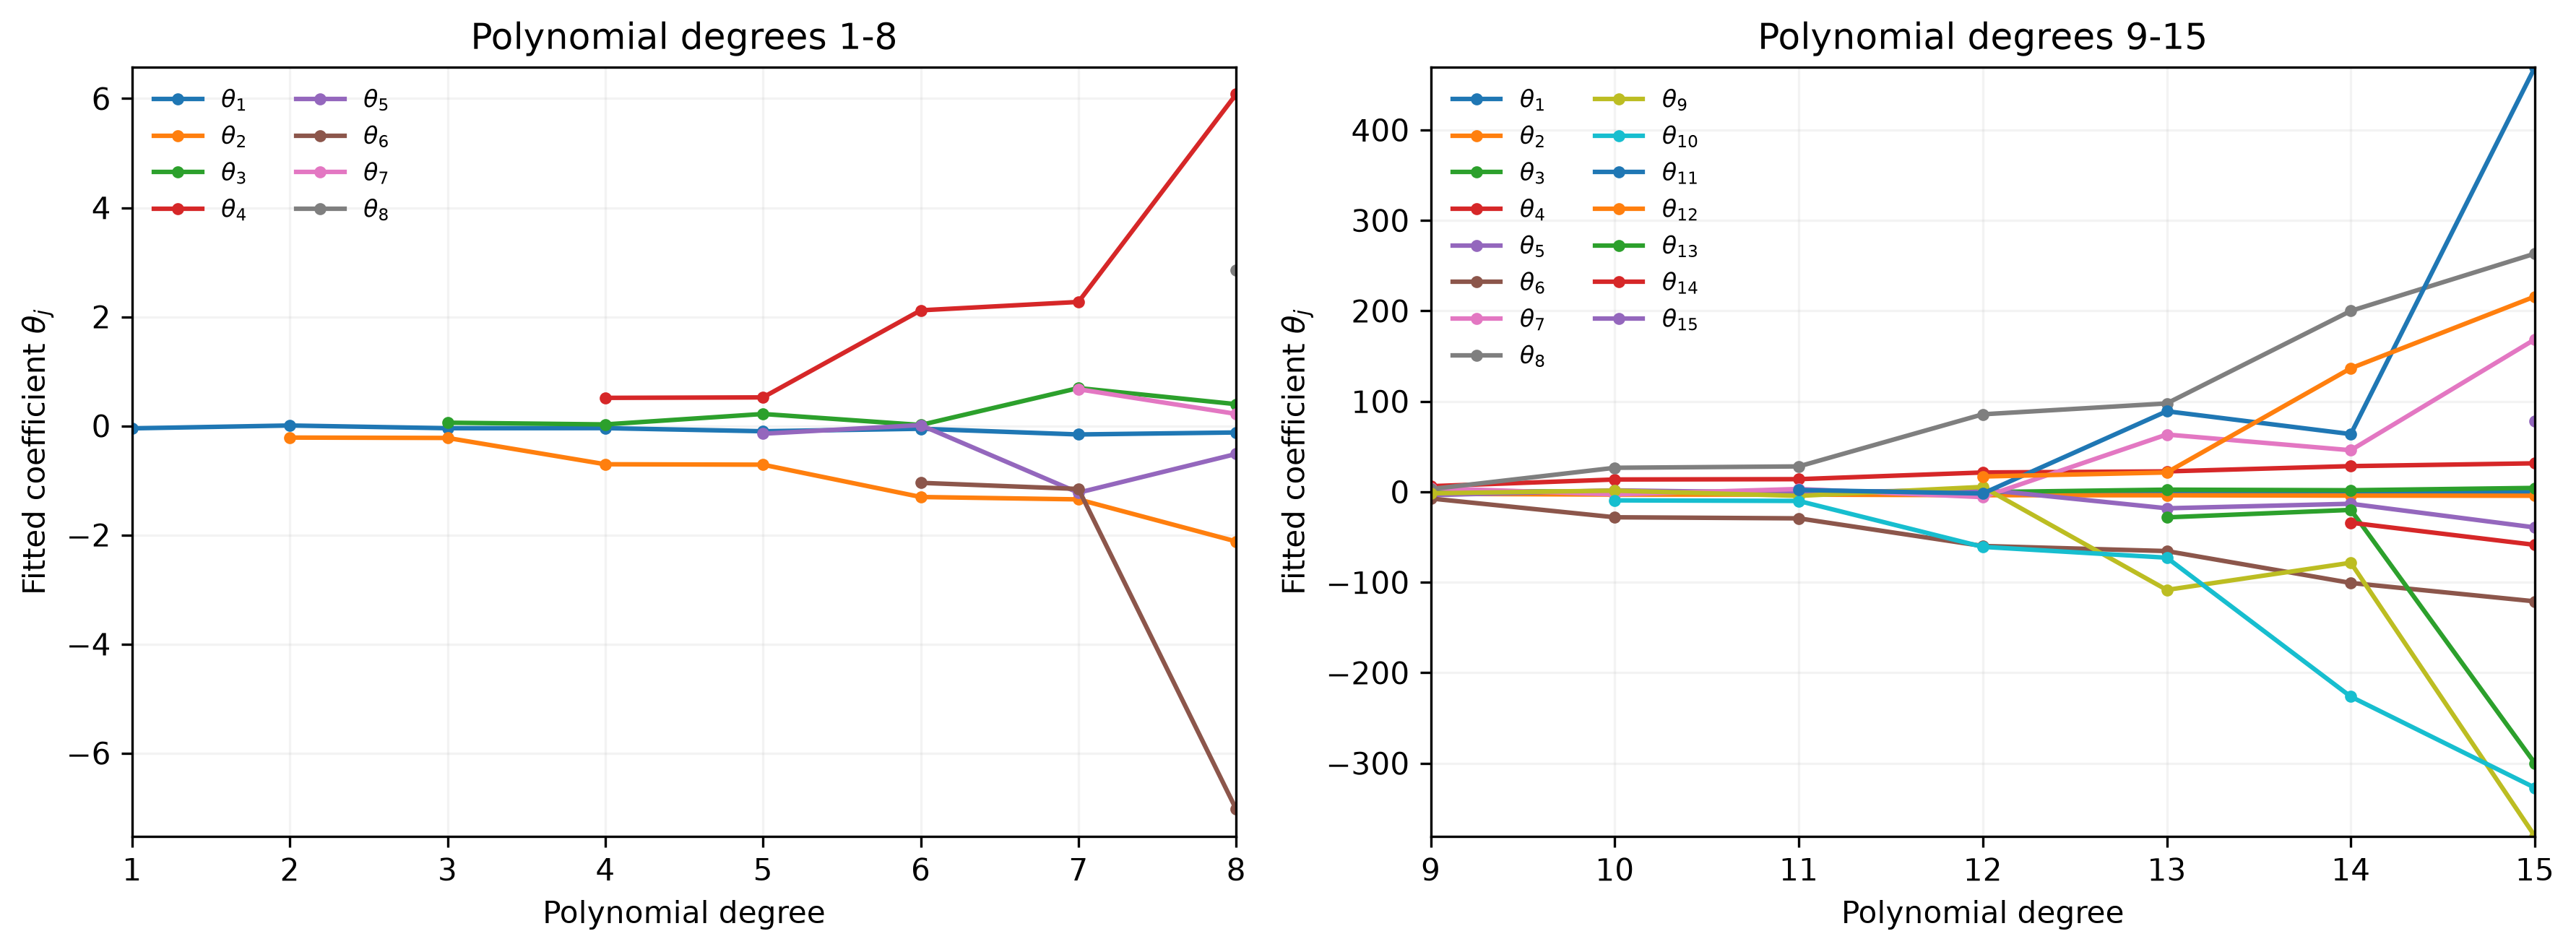

In [17]:
theta = result_a["theta"]
degrees = result_a["degrees"]

"""
LLM-generated
-------------
Tool: ChatGPT (september 2026)
Role: Helped with the masking
Modifications: removed complicated logic for y-lim padding; verified that the code works
"""

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for axis, (degree_min, degree_max) in zip(axes, ((1, 8), (9, MAX_DEGREE)), strict=True):
    mask = (degrees >= degree_min) & (degrees <= degree_max)
    panel_degrees = degrees[mask]
    coefficients = theta[mask]

    for coefficient in range(MAX_DEGREE):
        values = coefficients[:, coefficient]
        valid = np.isfinite(values)
        if valid.any():
            axis.plot(
                panel_degrees[valid],
                values[valid],
                "-o",
                linewidth=1.5,
                markersize=3,
                label=rf"$\theta_{{{coefficient + 1}}}$",
            )

    finite_values = coefficients[np.isfinite(coefficients)]
    axis.set_xlim(degree_min, degree_max)
    axis.set_ylim(finite_values.min() - 0.5, finite_values.max() + 0.5)
    axis.set_xlabel("Polynomial degree")
    axis.set_ylabel(r"Fitted coefficient $\theta_j$")
    axis.set_title(f"Polynomial degrees {degree_min}-{degree_max}")
    axis.grid(alpha=0.15)
    axis.legend(frameon=False, fontsize=8, ncol=2)

fig.tight_layout()
path_a_theta = save_figure(fig, FIGURES_DIR, "part_a_ols_theta.pdf")
plt.show()

The coefficient values are also shown as a heatmap to make the changes with degree easier to see.

Saved: /home/hmmorad/school/STK/fys-stk3155/project1/figures/part_a_ols_theta_heatmap.pdf


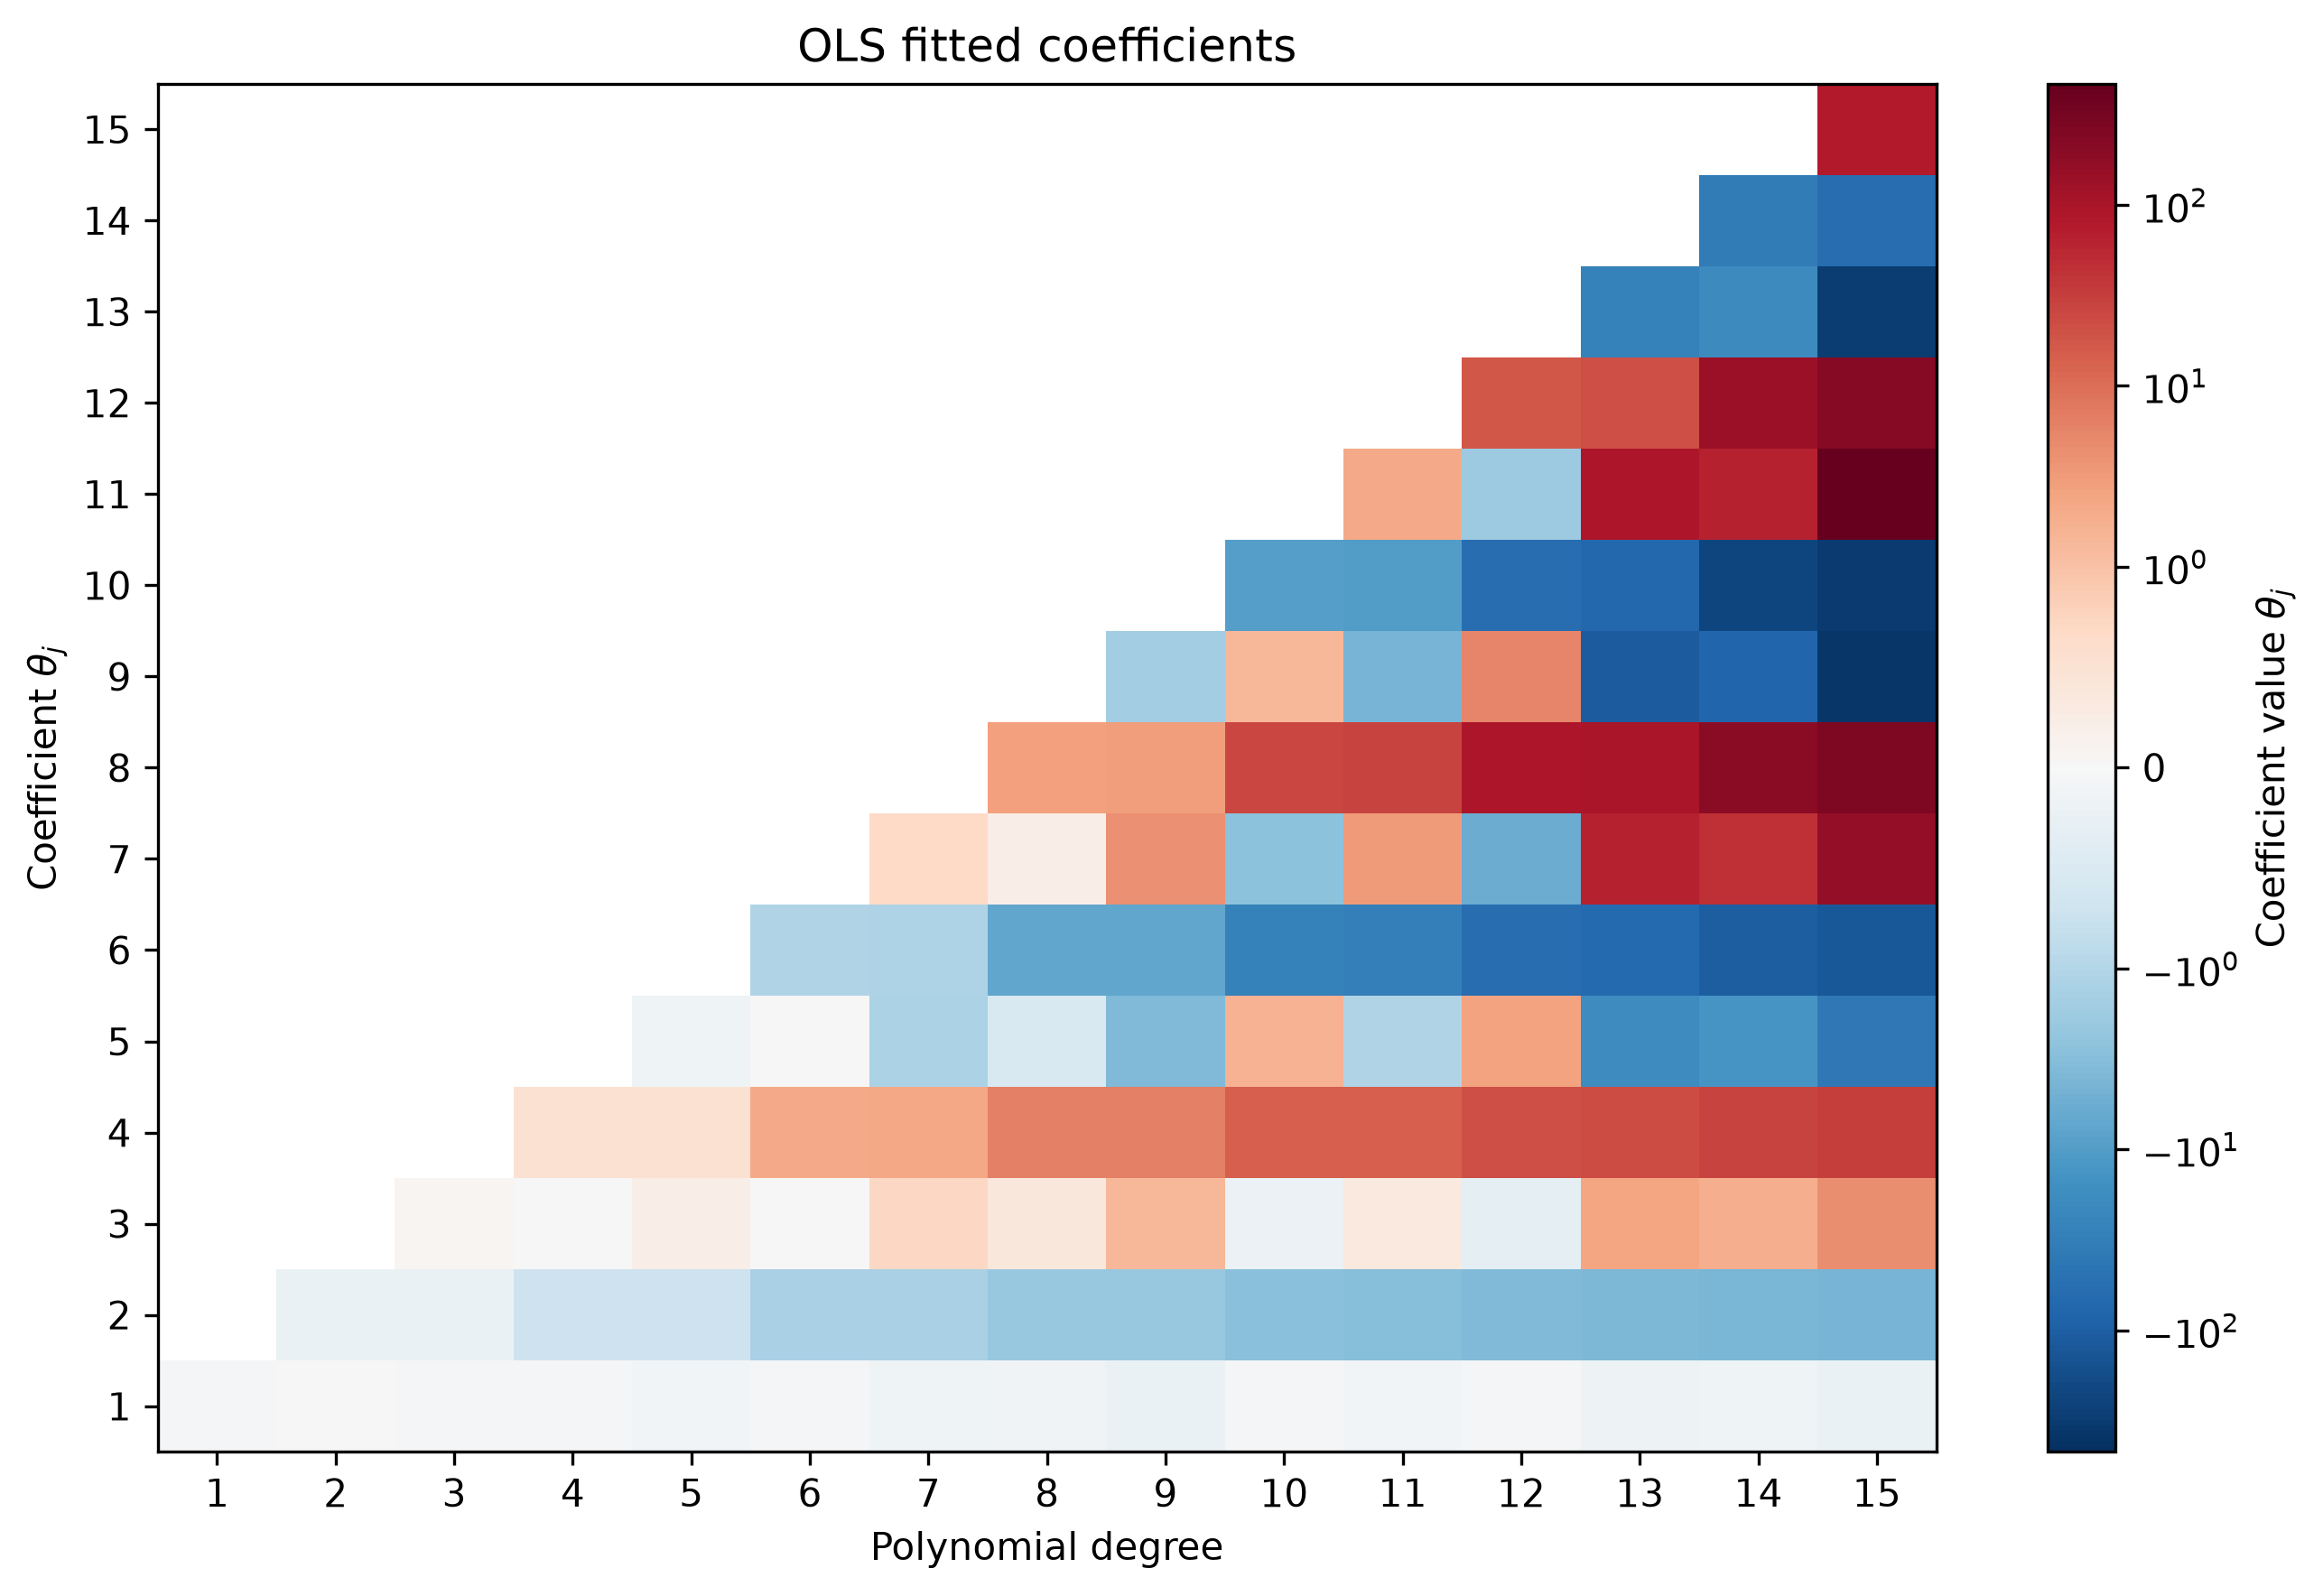

In [18]:
from matplotlib.colors import SymLogNorm

"""
LLM-generated
-------------
Tool: ChatGPT (september 2026)
Role: Generated the heatmap
Modifications: minimal manual edits; verified that it works
"""

theta_heatmap = np.ma.masked_invalid(theta.T)
max_abs = np.max(np.abs(theta_heatmap))
fig, ax = plt.subplots(figsize=(9, 6))
cmap = plt.cm.RdBu_r.copy()
cmap.set_bad("white")
image = ax.imshow(
    theta_heatmap,
    aspect="auto",
    origin="lower",
    extent=(degrees[0] - 0.5, degrees[-1] + 0.5, 0.5, MAX_DEGREE + 0.5),
    cmap=cmap,
    norm=SymLogNorm(linthresh=1, vmin=-max_abs, vmax=max_abs),
)

ax.set_xlabel("Polynomial degree")
ax.set_ylabel(r"Coefficient $\theta_j$")
ax.set_title("OLS fitted coefficients")
ax.set_xticks(degrees)
ax.set_yticks(np.arange(1, MAX_DEGREE + 1))
cbar = fig.colorbar(image, ax=ax)
cbar.set_label(r"Coefficient value $\theta_j$")

fig.tight_layout()

path_a_theta_heatmap = save_figure(fig, FIGURES_DIR, "part_a_ols_theta_heatmap.pdf")
plt.show()

# **Part b)**: Ridge regression

We now repeat the analysis with Ridge regularization and vary $\lambda$.

In [19]:
from matplotlib.colors import LogNorm

from project1.scripts import part_b

result_b = part_b.run(x, y, lambdas=LAMBDAS, max_degree=MAX_DEGREE, test_size=TEST_SIZE, seed=SEED)


Saved: /home/hmmorad/school/STK/fys-stk3155/project1/figures/part_b_ridge_test_mse_heatmap.pdf


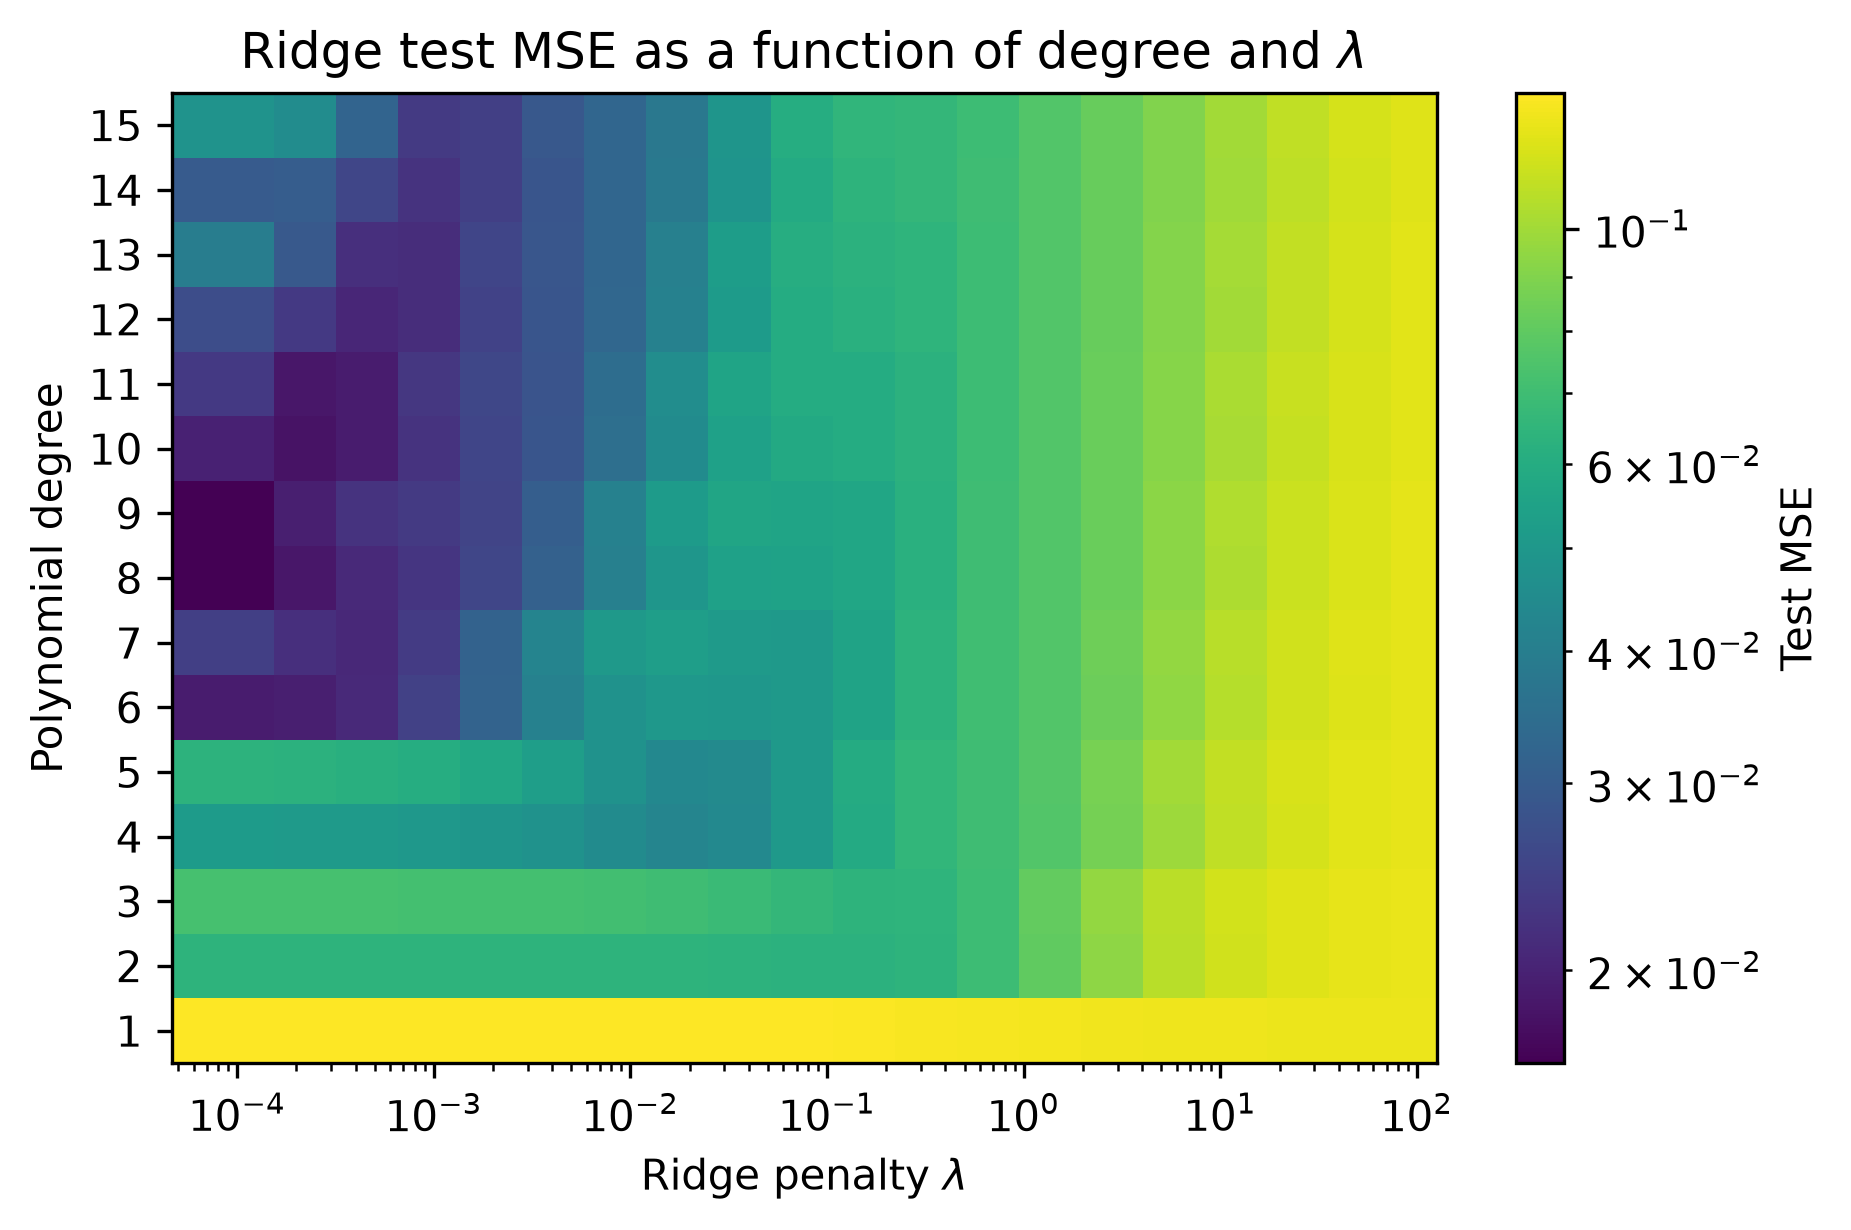

In [20]:
fig, ax = plt.subplots(figsize=(6.8, 4.2))
mesh = ax.pcolormesh(
    result_b["lambdas"],
    result_b["degrees"],
    result_b["test_mse"],
    norm=LogNorm(
        vmin=np.nanmin(result_b["test_mse"]),
        vmax=np.nanmax(result_b["test_mse"]),
    ),
)
ax.set_xscale("log")
ax.set_xlabel(r"Ridge penalty $\lambda$")
ax.set_ylabel("Polynomial degree")
ax.set_title(r"Ridge test MSE as a function of degree and $\lambda$")
ax.set_yticks(result_b["degrees"])
fig.colorbar(mesh, ax=ax, label="Test MSE")

path_b_heatmap = save_figure(fig, FIGURES_DIR, "part_b_ridge_test_mse_heatmap.pdf")
plt.show()

The heatmap shows the full degree-$\lambda$ grid. A few selected $\lambda$ values are shown below for easier comparison.

Saved: /home/hmmorad/school/STK/fys-stk3155/project1/figures/part_b_ridge_selected_lambda.pdf


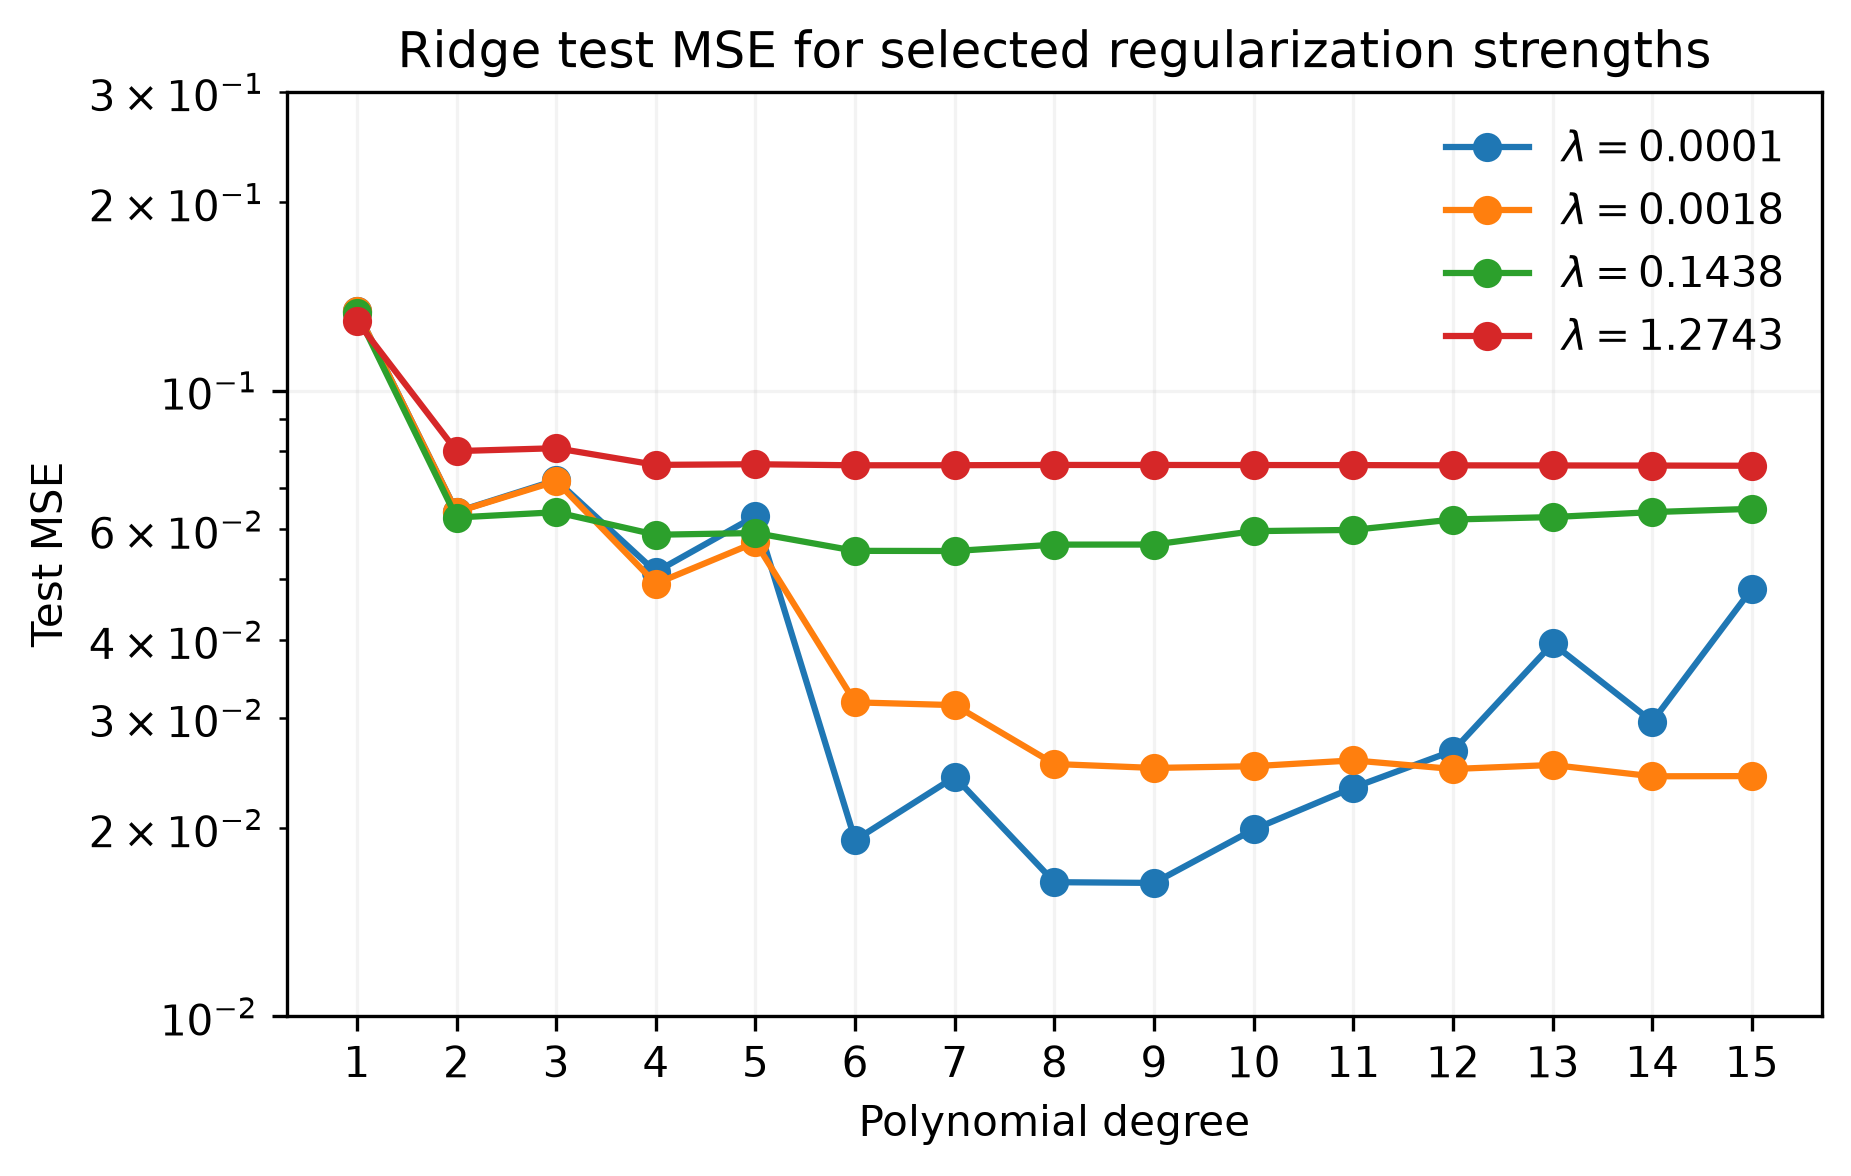

In [21]:
SELECTED_LAMBDAS = {0: LAMBDAS[0], 4: LAMBDAS[4], 10: LAMBDAS[10], 13: LAMBDAS[13]}
fig, ax = plt.subplots(figsize=(6.6, 4.0))

for j, lam in SELECTED_LAMBDAS.items():
    ax.plot(
        result_b["degrees"],
        result_b["test_mse"][:, j],
        "o-",
        label=rf"$\lambda={lam:.4f}$",
    )

ax.set_title("Ridge test MSE for selected regularization strengths")
ax.set_xlabel("Polynomial degree")
ax.set_ylabel("Test MSE")
ax.set_yscale("log")
ax.set_xticks(result_b["degrees"])
ax.legend(frameon=False)
ax.set_ylim(bottom=1e-2, top=3e-1)
ax.grid(alpha=0.15)

path_b_curves = save_figure(fig, FIGURES_DIR, "part_b_ridge_selected_lambda.pdf")
plt.show()

# **Part c)**: Bootstrap bias-variance analysis

We use bootstrap resampling to see how the bias and variance change with polynomial degree.


In [22]:
from project1.scripts import part_c

result_c = part_c.run(
    x, y, max_degree=MAX_DEGREE, n_bootstraps=1000, test_size=TEST_SIZE, seed=SEED
)

Saved: /home/hmmorad/school/STK/fys-stk3155/project1/figures/part_c_bootstrap_bias_variance.pdf


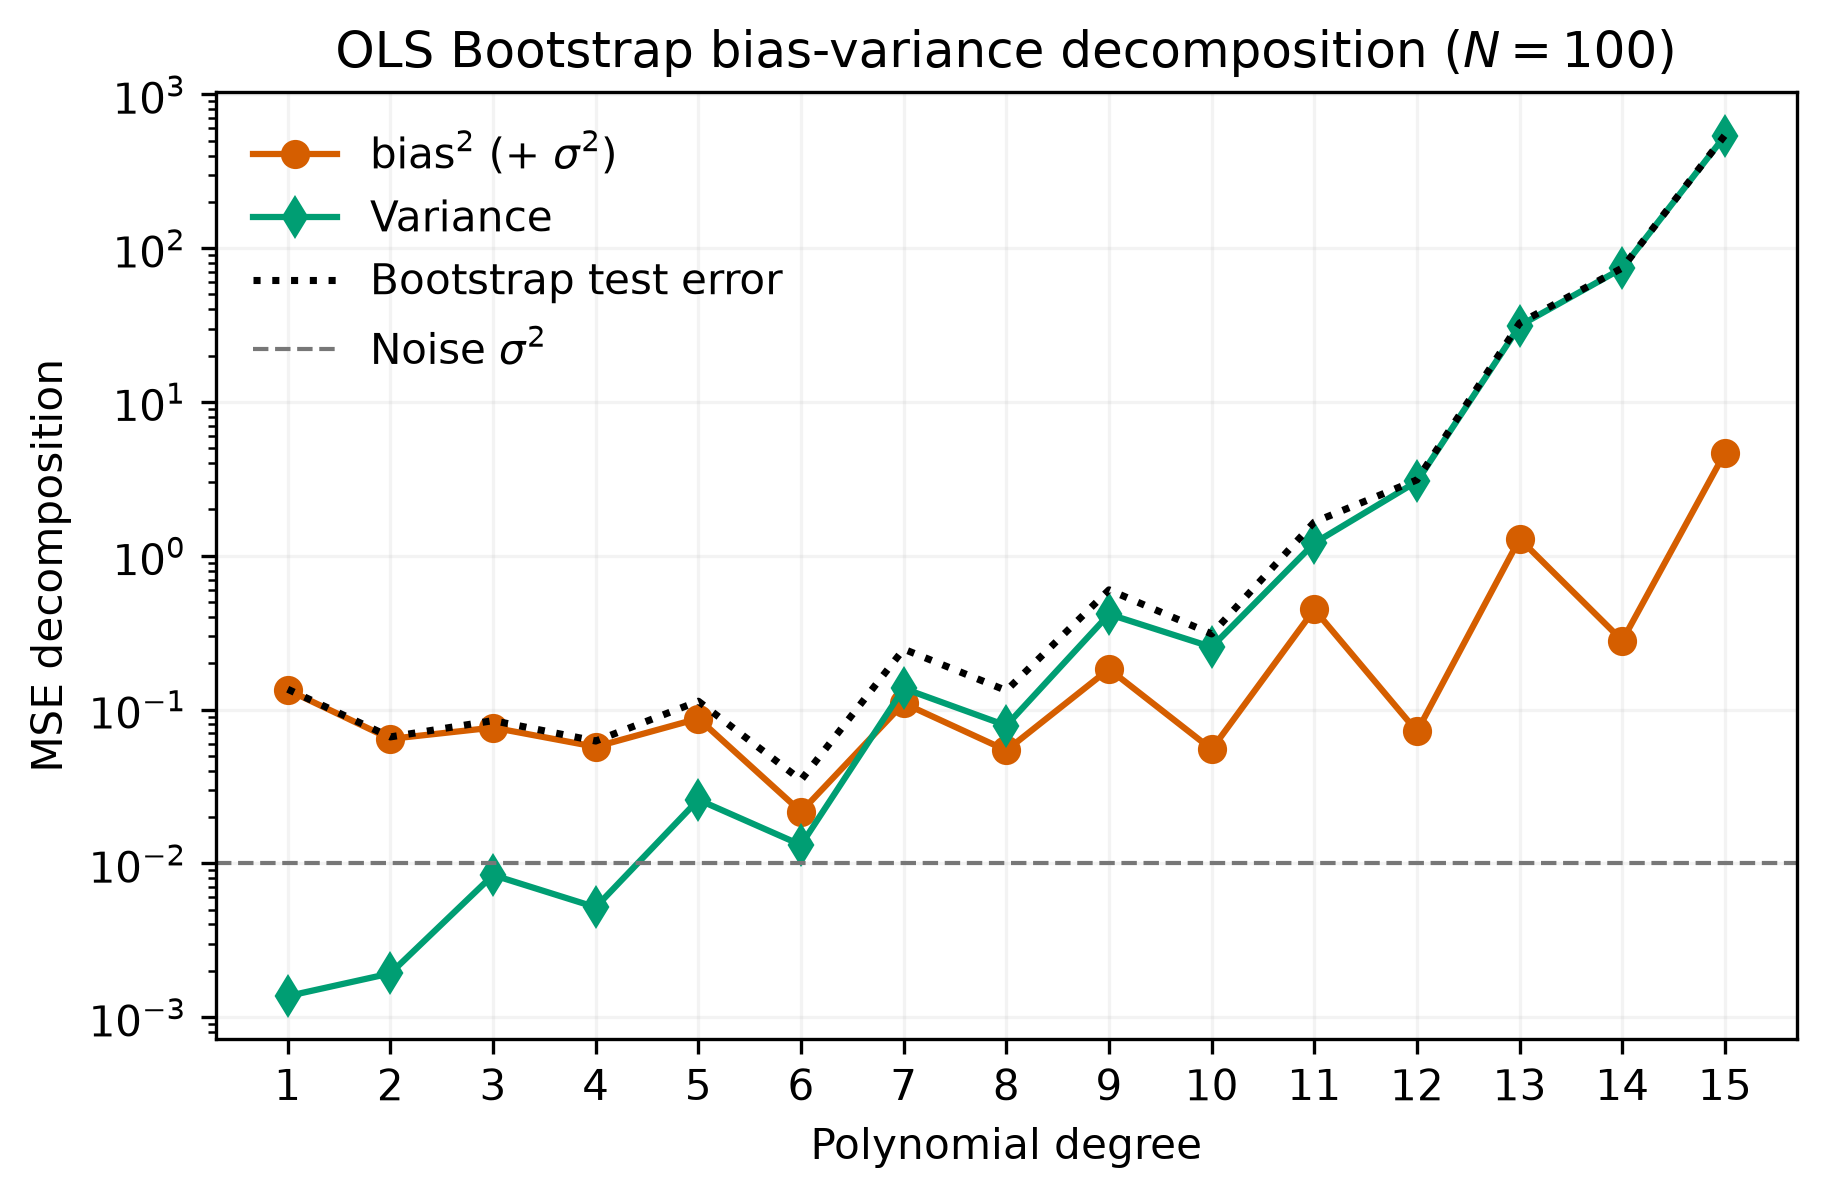

In [ ]:
fig, ax = plt.subplots(figsize=(6.8, 4.1))

degrees = result_c["degrees"]
error = result_c["error"]
bias2 = result_c["bias2"]  ### bias squared + noise squared
variance = result_c["variance"]

ax.plot(degrees, bias2, "o-", color=BIAS_COLOR, label=r"bias$^2$ (+ $\sigma^2$)")
ax.plot(degrees, variance, "d-", color=VARIANCE_COLOR, label="Variance")
ax.plot(degrees, error, ":", color=ERROR_COLOR, linewidth=1.7, label="Bootstrap test error")
ax.axhline(NOISE**2, color=GREY, linestyle="--", linewidth=1, label=r"Noise $\sigma^2$")

ax.set_title(r"OLS Bootstrap bias-variance decomposition ($N=100$)")
ax.set_xlabel("Polynomial degree")
ax.set_ylabel("MSE decomposition")
ax.set_yscale("log")
ax.set_xticks(degrees)
ax.legend(frameon=False)
ax.grid(alpha=0.15)

path_c = save_figure(fig, FIGURES_DIR, "part_c_bootstrap_bias_variance.pdf")
plt.show()

### Sample-size sensitivity

The project also asks us to see how the bias-variance trade-off changes with sample size, so we repeat the bootstrap analysis for $N=200$ and $N=500$.

In [24]:
result_c_n200 = part_c.run(
    *runge_function(n=200, noise=NOISE, seed=SEED),
    max_degree=MAX_DEGREE,
    n_bootstraps=500,
    test_size=TEST_SIZE,
    seed=SEED,
)
result_c_n500 = part_c.run(
    *runge_function(n=500, noise=NOISE, seed=SEED),
    max_degree=MAX_DEGREE,
    n_bootstraps=500,
    test_size=TEST_SIZE,
    seed=SEED,
)

Saved: /home/hmmorad/school/STK/fys-stk3155/project1/figures/part_c_sample_size_comparison.pdf


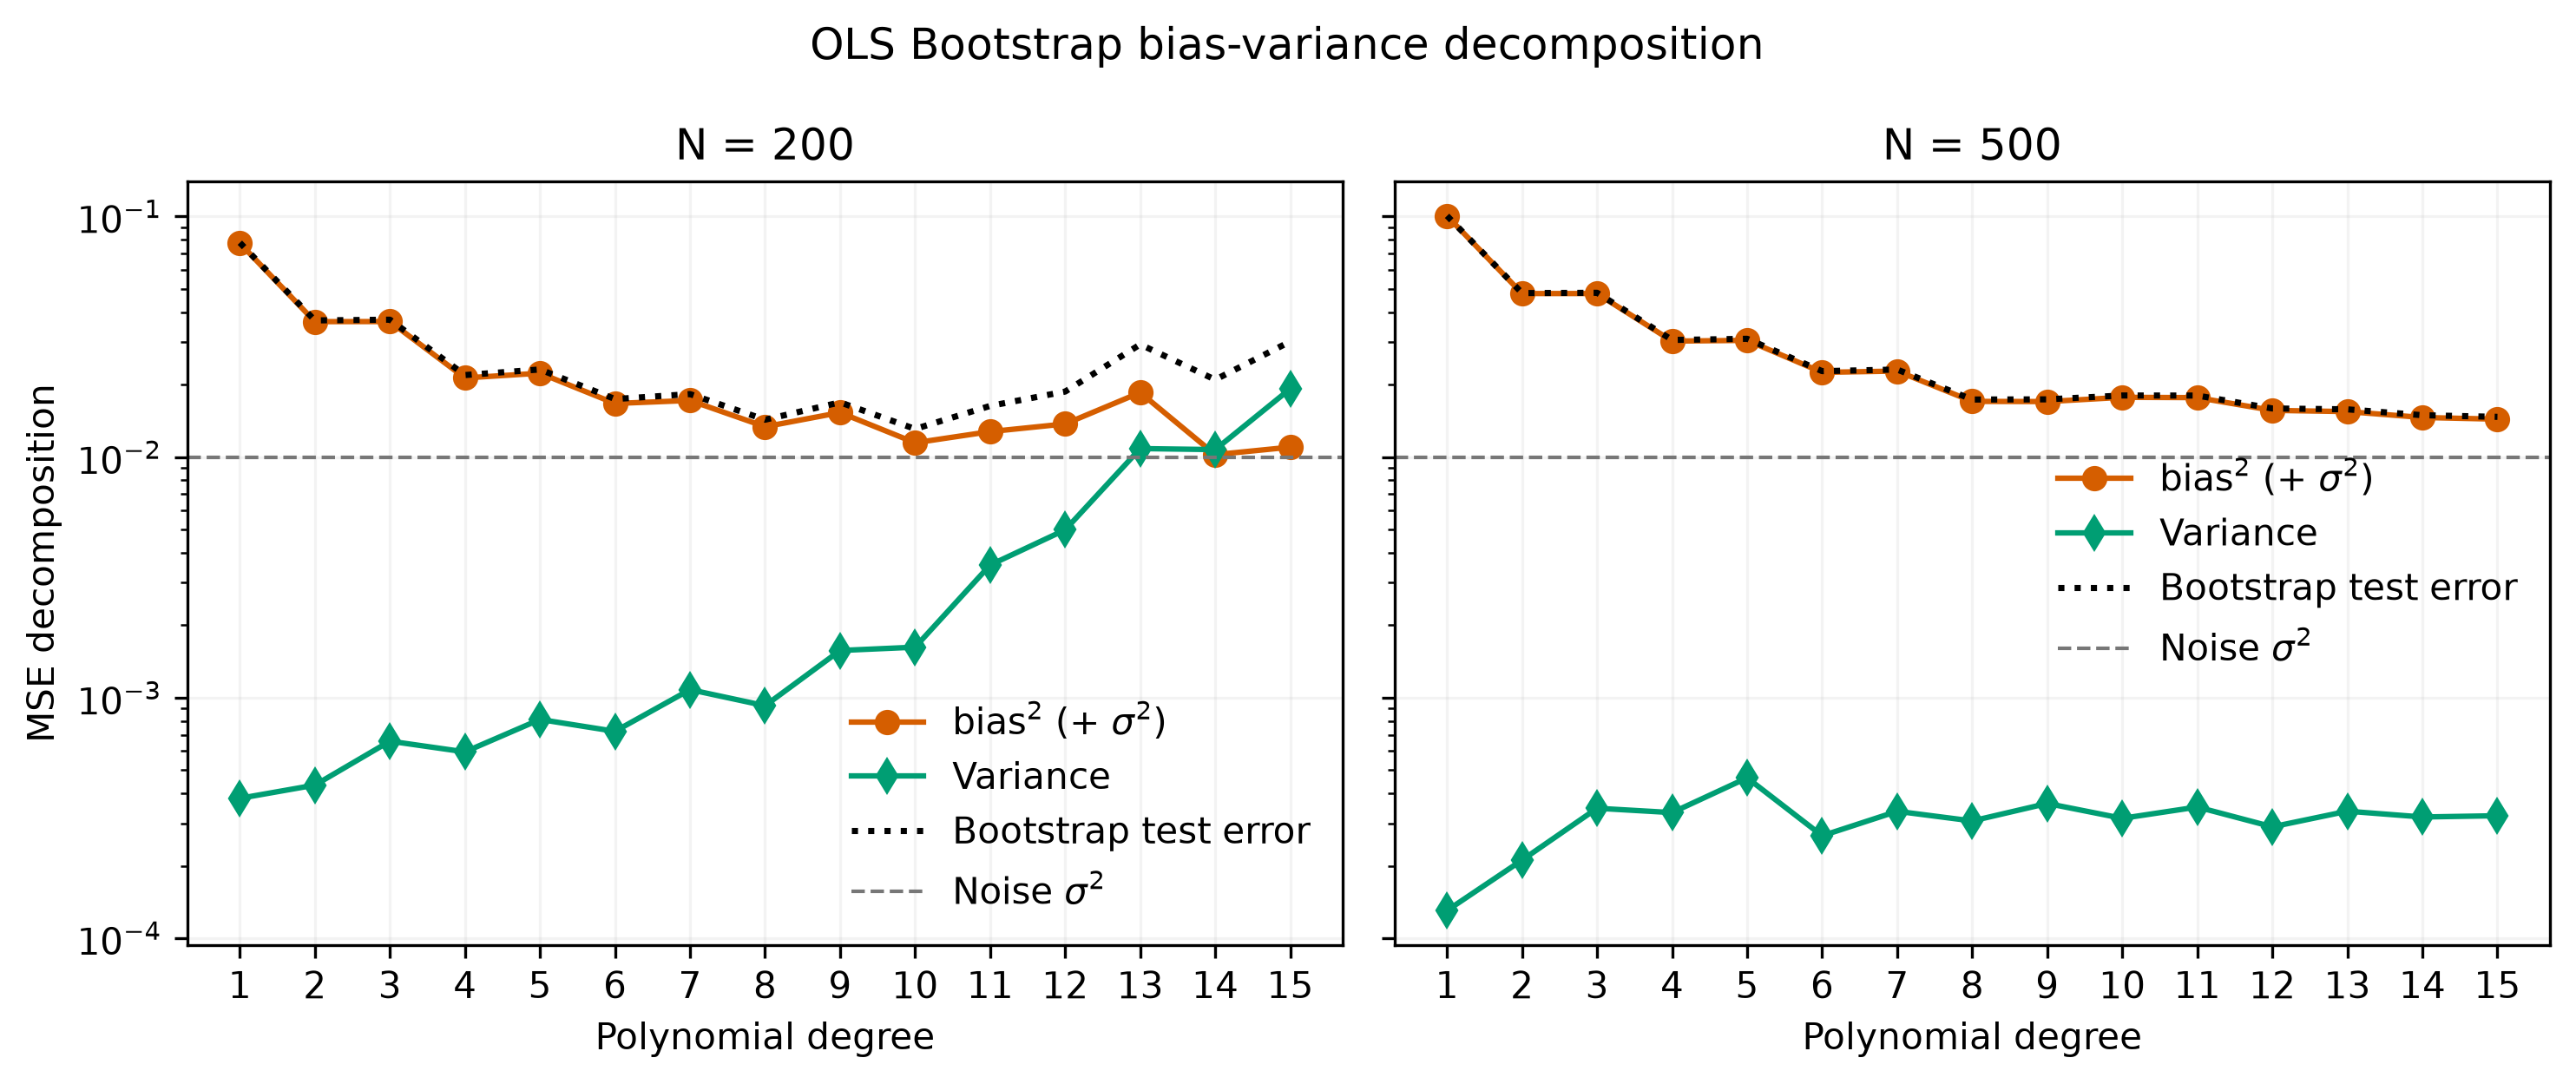

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.2), sharey=True)

for ax, result, n_value in (
    (axes[0], result_c_n200, 200),
    (axes[1], result_c_n500, 500),
):
    degrees = result["degrees"]
    bias2 = result["bias2"]
    variance = result["variance"]
    error = result["error"]

    ax.plot(degrees, bias2, "o-", color=BIAS_COLOR, label=r"bias$^2$ (+ $\sigma^2$)")
    ax.plot(degrees, variance, "d-", color=VARIANCE_COLOR, label="Variance")
    ax.plot(degrees, error, ":", color=ERROR_COLOR, linewidth=1.7, label="Bootstrap test error")
    ax.axhline(NOISE**2, color=GREY, linestyle="--", linewidth=1, label=r"Noise $\sigma^2$")

    ax.set_xticks(degrees)
    ax.set_yscale("log")
    ax.set_xlabel("Polynomial degree")
    ax.set_title(f"N = {n_value}")
    ax.legend(frameon=False)
    ax.grid(alpha=0.15)

axes[0].set_ylabel("MSE decomposition")

fig.suptitle("OLS Bootstrap bias-variance decomposition")
fig.tight_layout()

path_c_sample_size = save_figure(fig, FIGURES_DIR, "part_c_sample_size_comparison.pdf")

plt.show()

# **Part d)**: Cross-validation

Next, we use 5-fold and 10-fold cross-validation and compare the OLS error estimates with the bootstrap results.

In [26]:
from project1.scripts import part_d

result_d = part_d.run(x, y, lambdas=LAMBDAS, max_degree=MAX_DEGREE, seed=SEED, test_size=TEST_SIZE)

Saved: /home/hmmorad/school/STK/fys-stk3155/project1/figures/part_d_ols_cv_vs_bootstrap.pdf


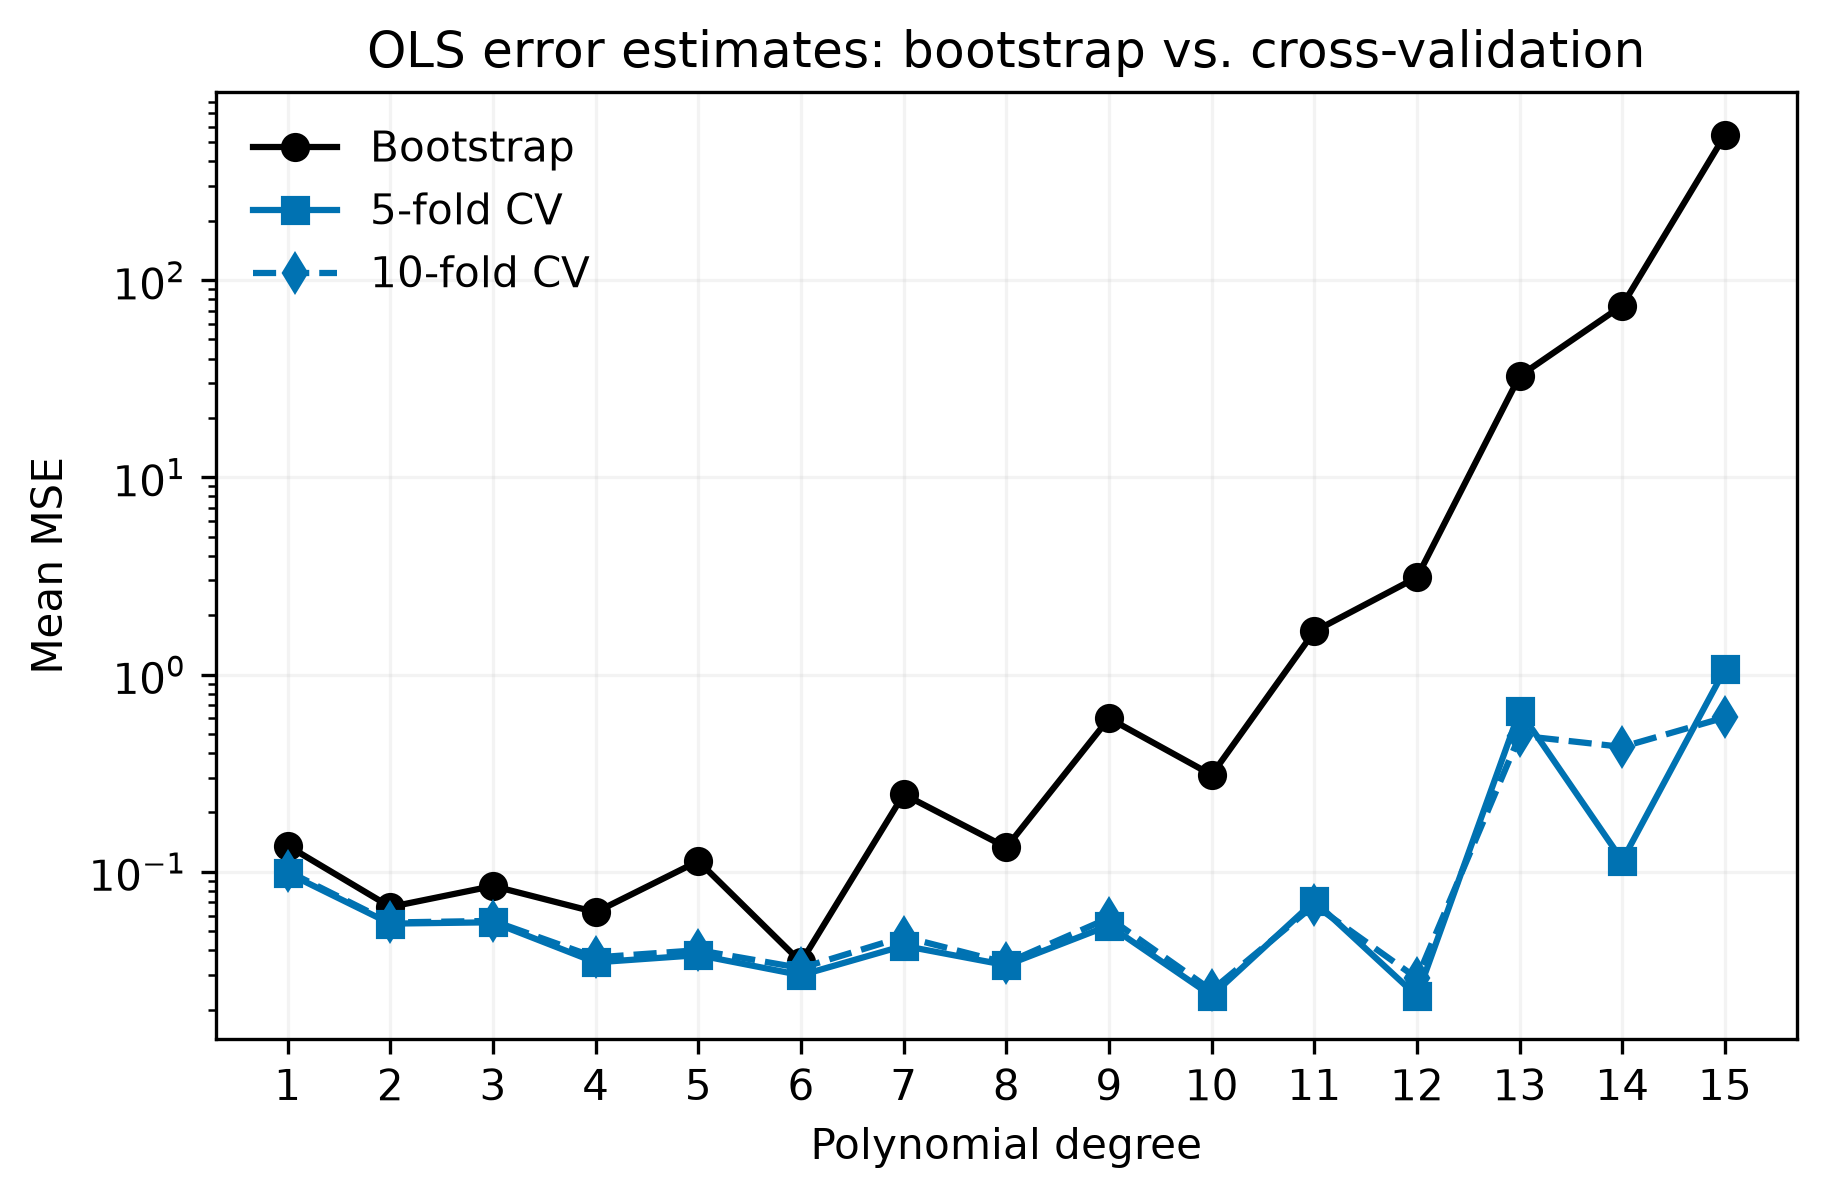

In [27]:
fig, ax = plt.subplots(figsize=(6.8, 4.1))

ax.plot(result_c["degrees"], result_c["error"], "o-", color=ERROR_COLOR, label="Bootstrap")
ax.plot(result_d["degrees"], result_d["ols_mse_5"], "s-", color=OLS_COLOR, label="5-fold CV")
ax.plot(result_d["degrees"], result_d["ols_mse_10"], "d--", color=OLS_COLOR, label="10-fold CV")

ax.set_title("OLS error estimates: bootstrap vs. cross-validation")
ax.set_xlabel("Polynomial degree")
ax.set_ylabel("Mean MSE")
ax.set_yscale("log")
ax.set_xticks(result_d["degrees"])
ax.legend(frameon=False)
ax.grid(alpha=0.15)

path_d_ols = save_figure(fig, FIGURES_DIR, "part_d_ols_cv_vs_bootstrap.pdf")
plt.show()

For Ridge, we vary both the polynomial degree and $\lambda$.

Saved: /home/hmmorad/school/STK/fys-stk3155/project1/figures/part_d_ridge_cv_heatmaps.pdf


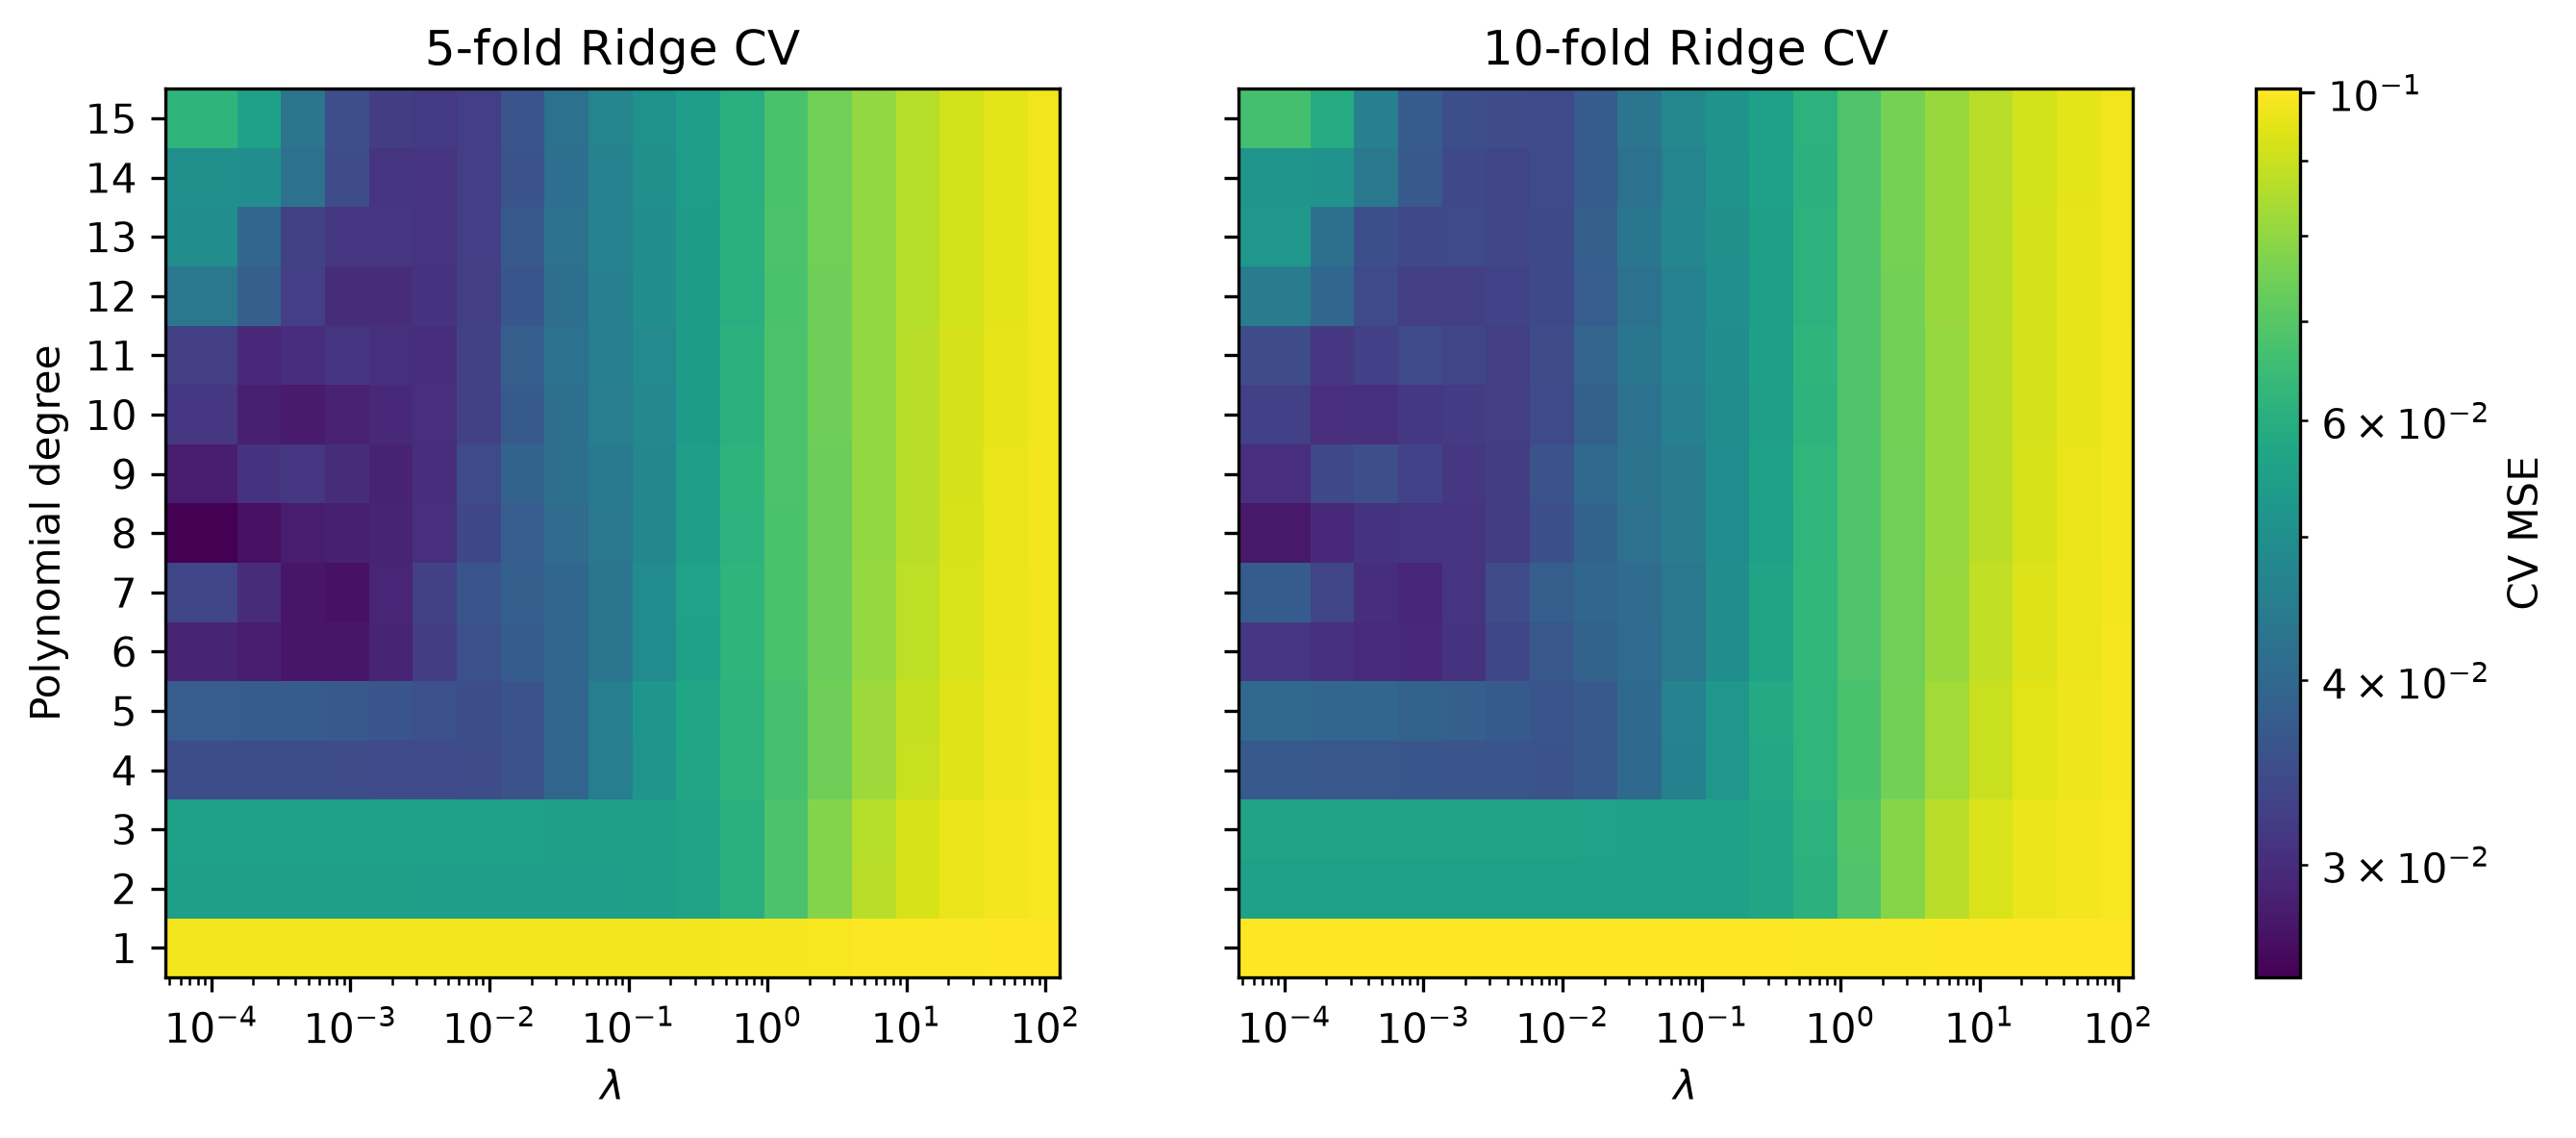

Lowest 10-fold CV MSE found at BEST_DEGREE: 8 and BEST_LAMBDA: 0.0001


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), sharey=True)

vmin = min(np.min(result_d["ridge_mse_5"]), np.min(result_d["ridge_mse_10"]))
vmax = max(np.max(result_d["ridge_mse_5"]), np.max(result_d["ridge_mse_10"]))

for axis, values, k in zip(
    axes,
    (result_d["ridge_mse_5"], result_d["ridge_mse_10"]),
    (5, 10),
    strict=True,
):
    mesh = axis.pcolormesh(
        result_d["lambdas"],
        result_d["degrees"],
        values,
        norm=LogNorm(vmin=vmin, vmax=vmax),
    )
    axis.set_xscale("log")
    axis.set_xlabel(r"$\lambda$")
    axis.set_title(f"{k}-fold Ridge CV")
    axis.set_yticks(result_d["degrees"])

axes[0].set_ylabel("Polynomial degree")
fig.colorbar(mesh, ax=axes, label="CV MSE")

path_d_ridge = save_figure(fig, FIGURES_DIR, "part_d_ridge_cv_heatmaps.pdf")
plt.show()

best_degree_idx, best_lambda_idx = np.unravel_index(
    np.nanargmin(result_d["ridge_mse_10"]), result_d["ridge_mse_10"].shape
)

BEST_CV_RIDGE_LAMBDA = result_d["lambdas"][best_lambda_idx]
BEST_CV_RIDGE_DEGREE = result_d["degrees"][best_degree_idx]

print(
    f"Lowest 10-fold CV MSE found at BEST_DEGREE: "
    f"{BEST_CV_RIDGE_DEGREE} and BEST_LAMBDA: {BEST_CV_RIDGE_LAMBDA}"
)

# **Part e)**: Gradient descent and automatic differentiation

Here we replace the closed-form solution with gradient descent and compare the analytical gradient with the JAX gradient.

In [20]:
import importlib
import project1.scripts.part_e

importlib.reload(project1.scripts.part_e)
from project1.scripts import part_e

OPTIMIZER_LAM = 0.01  # we use this lambda for part e and f
OPTIMIZER_DEGREE = 10
result_e = part_e.run(x, y, degree=OPTIMIZER_DEGREE, lam=OPTIMIZER_LAM, max_iter=1500, tol=1e-18)

print("Gradient checks:")
print(part_e.gradient_check(x, y, degree=OPTIMIZER_DEGREE, lam=OPTIMIZER_LAM, seed=SEED))

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Gradient checks:
{'ols_max_abs_error': 2.6645352591003757e-15, 'ridge_max_abs_error': 2.6645352591003757e-15}


Saved: /home/hmmorad/school/STK/fys-stk3155/project1/figures/part_e_gd_distance_to_closed_form.pdf


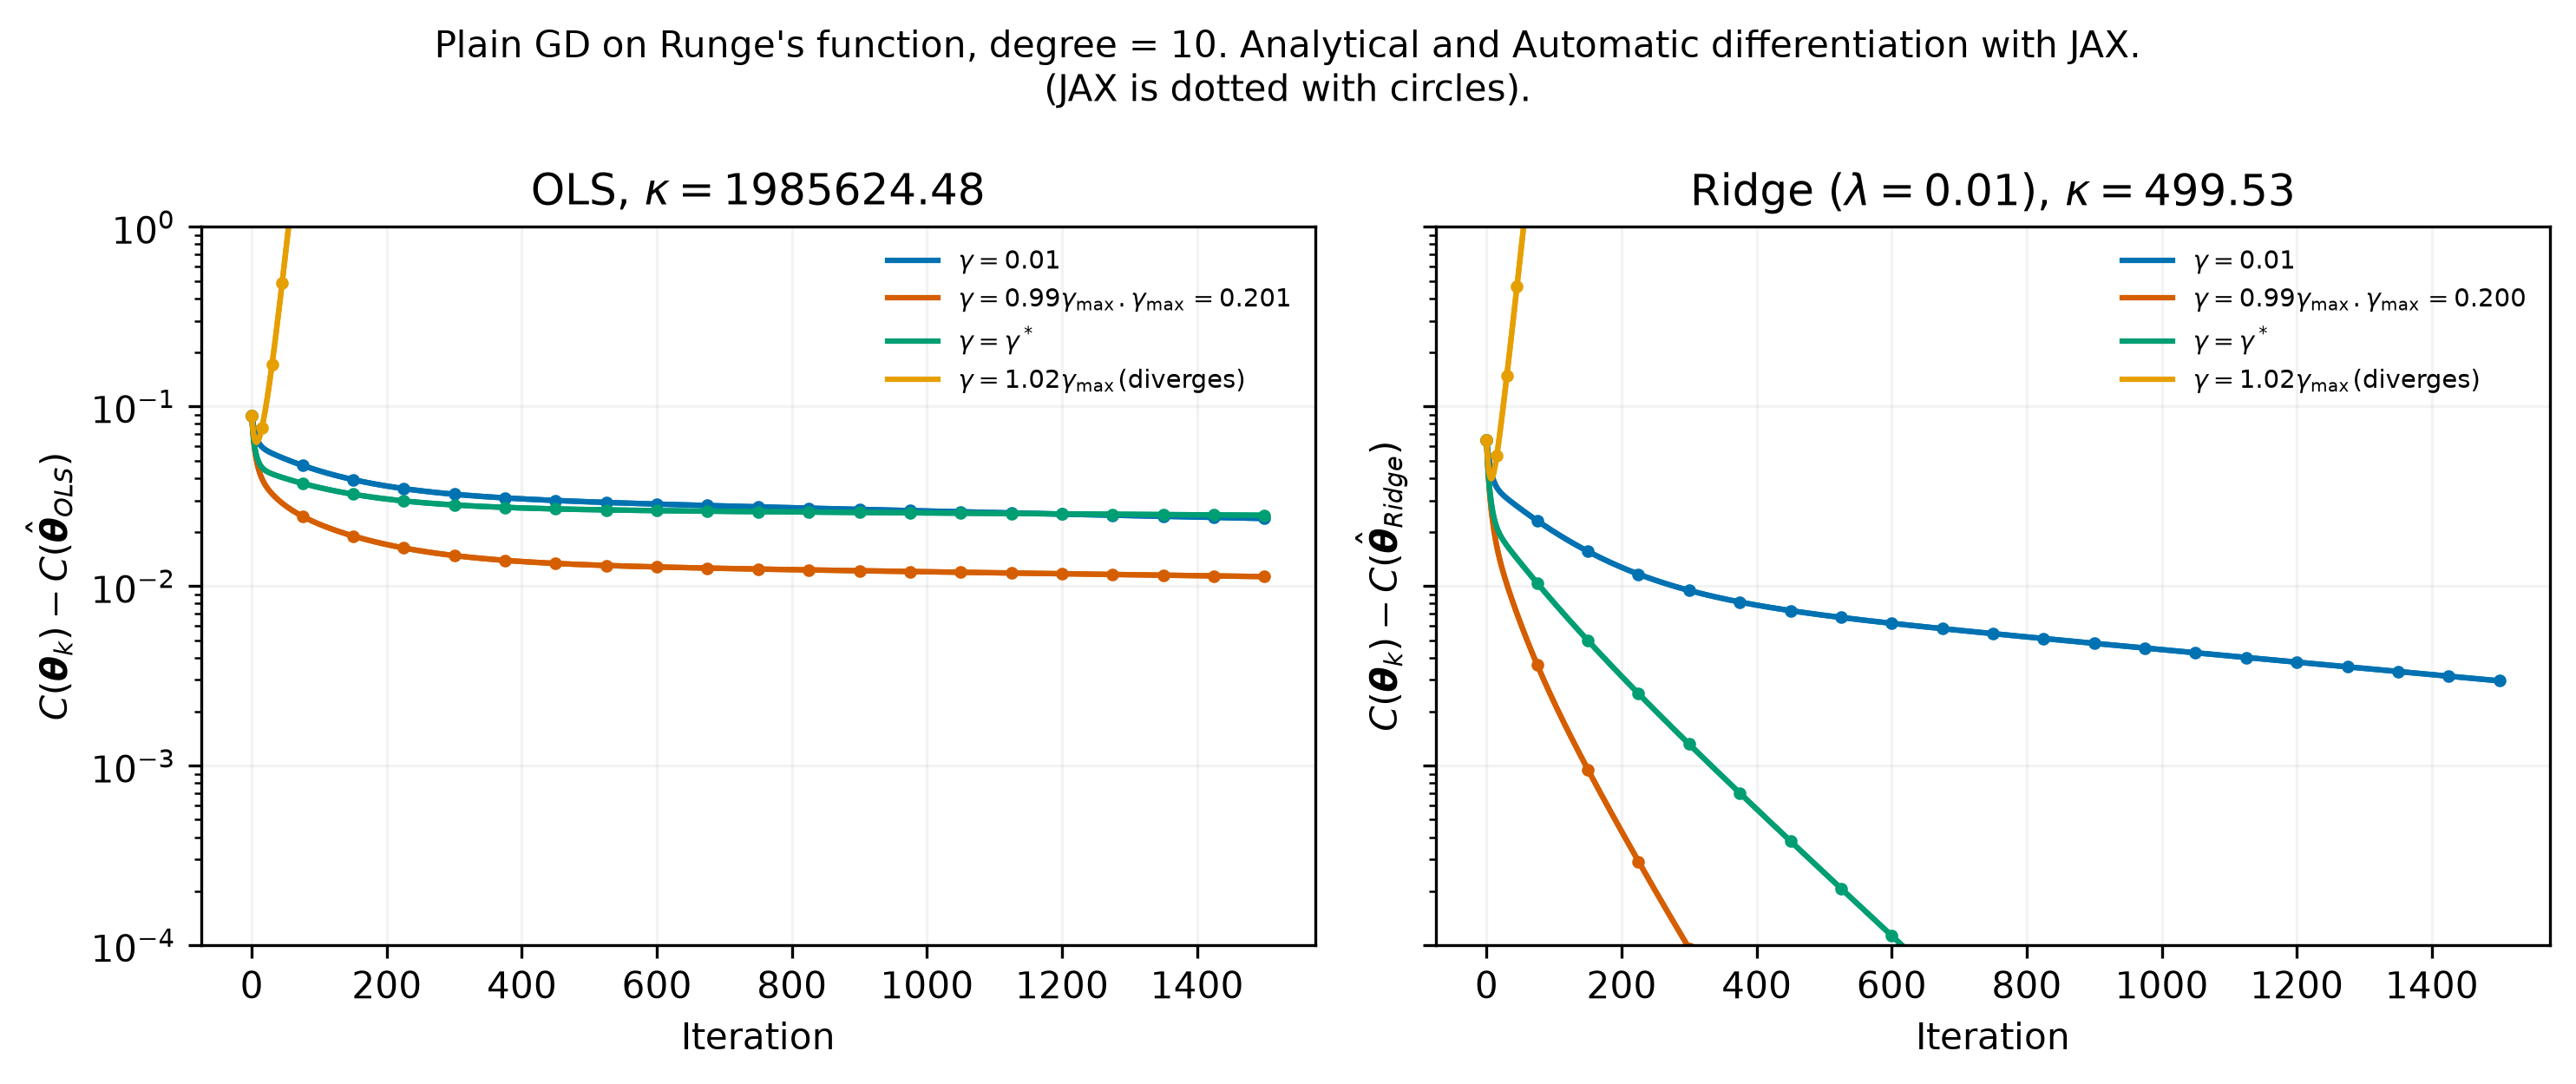

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)

gamma_colors = [BLUE, RED, GREEN, YELLOW]

for axis, regr_type in zip(axes, ("OLS", "Ridge"), strict=True):
    analytic = result_e[regr_type]["analytic"]
    autodiff = result_e[regr_type]["autodiff"]
    for color, gamma_label in zip(gamma_colors, analytic, strict=True):
        analytical = analytic[gamma_label]
        jax = autodiff[gamma_label]

        iterations_a = np.arange(len(analytical["excess_cost"]))
        iterations_j = np.arange(len(jax["excess_cost"]))

        axis.semilogy(
            iterations_j,
            jax["excess_cost"],
            color=color,
            marker="o",
            markersize=2.5,
            markevery=len(iterations_j) // 20,
        )

        axis.semilogy(
            iterations_a,
            analytical["excess_cost"],
            color=color,
            linewidth=1.5,
            label=rf"${gamma_label}$",
        )
    title_sub = rf" ($\lambda ={OPTIMIZER_LAM}$)" if regr_type == "Ridge" else ""
    axis.set_title(rf"{regr_type}{title_sub}, $\kappa = {result_e[regr_type]['kappa']:.2f}$")
    axis.set_xlabel("Iteration")
    axis.set_ylim(bottom=1e-4, top=1e0)
    axis.legend(frameon=False, fontsize=7)
    axis.grid(alpha=0.15)
    axis.set_ylabel(
        rf"$C(\boldsymbol{{\theta}}_k)-C(\hat{{\boldsymbol{{\theta}}}}_{{{regr_type}}})$"
    )

fig.suptitle(
    f"Plain GD on Runge's function, degree = {OPTIMIZER_DEGREE}. "
    f"Analytical and Automatic differentiation with JAX.\n(JAX is dotted with circles).",
    fontsize=10,
)

fig.tight_layout()

path_e = save_figure(fig, FIGURES_DIR, "part_e_gd_distance_to_closed_form.pdf")

plt.show()

# **Part f)**: Momentum and adaptive optimizers

We compare the optimizers on 10-degree Runge and study how sensitive they are to the learning rate.

In [22]:
from project1.models import OLS, Ridge
from project1.utils.polynomial import polynomial_matrix
from project1.utils.scaling import scale_data

import importlib
import project1.scripts.part_f

importlib.reload(project1.scripts.part_f)
from project1.scripts import part_f

colors = {
    "GD": GD_COLOR,
    "Momentum": MOMENTUM_COLOR,
    "AdaGrad": ADAGRAD_COLOR,
    "RMSProp": RMSPROP_COLOR,
    "Adam": ADAM_COLOR,
}

In [23]:
result_f_ols = part_f.run_comparison(
    x, y, degree=OPTIMIZER_DEGREE, max_iter=4000, tol=1e-8, model_class=OLS
)

result_f_ridge = part_f.run_comparison(
    x,
    y,
    degree=OPTIMIZER_DEGREE,
    max_iter=2000,
    tol=1e-8,
    model_class=Ridge,
    model_kwargs={"lam": OPTIMIZER_LAM},
)


Saved: /home/hmmorad/school/STK/fys-stk3155/project1/figures/part_f_optimizer_convergence.pdf


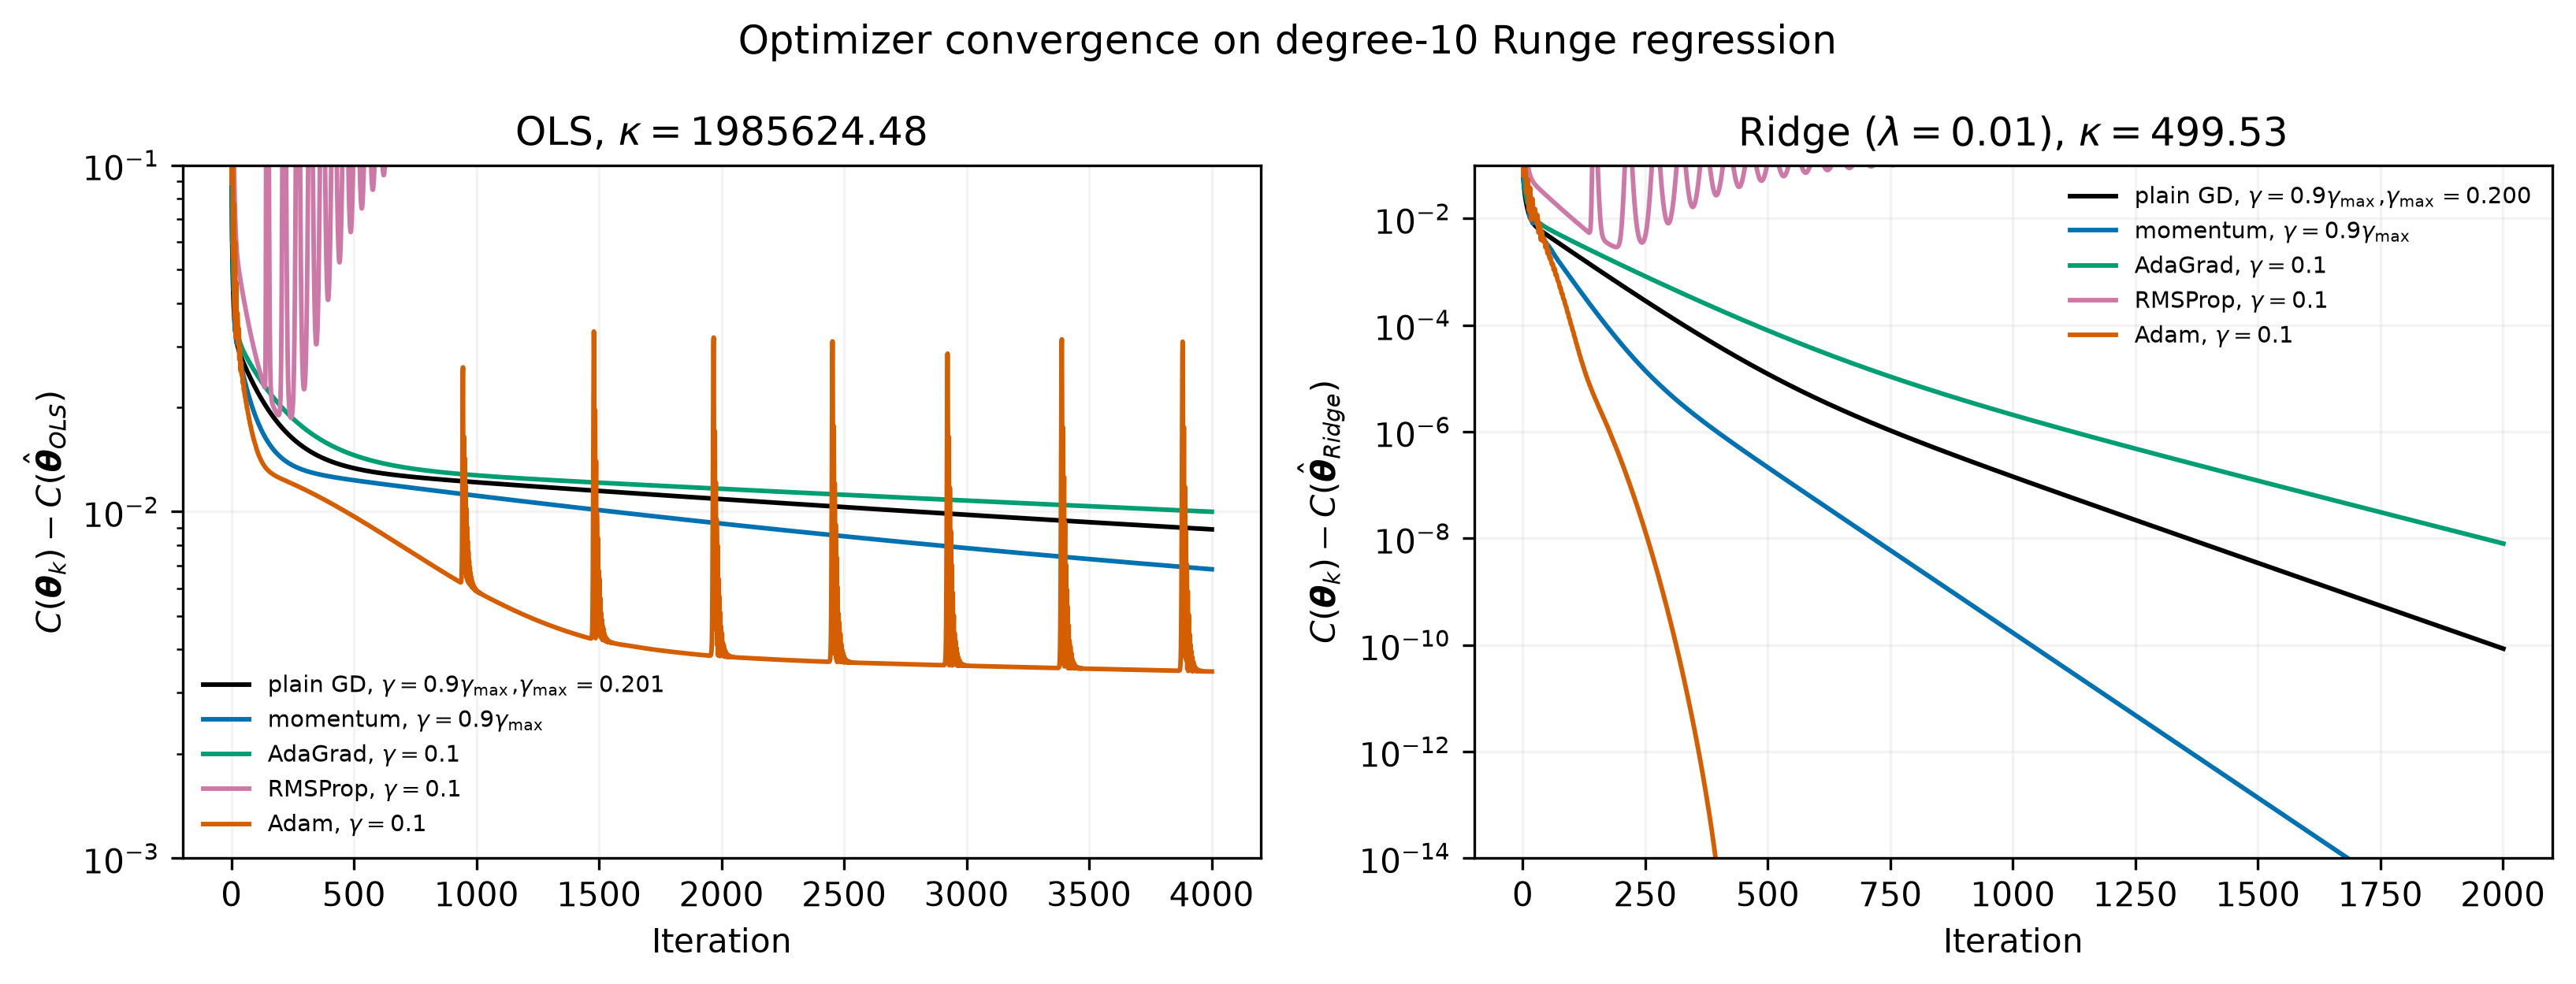

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for axis, result, regr_type, ylim in zip(
    axes,
    (result_f_ols, result_f_ridge),
    ("OLS", "Ridge"),
    ({"bottom": 1e-3, "top": 1e-1}, {"bottom": 1e-14, "top": 1e-1}),
    strict=True,
):
    for method, items in result["results"].items():
        axis.semilogy(
            np.arange(1, len(items["excess_cost"]) + 1),
            items["excess_cost"],
            color=colors[method],
            linewidth=1.4,
            label=items["label"],
        )
    title_sub = rf" ($\lambda ={OPTIMIZER_LAM}$)" if regr_type == "Ridge" else ""
    axis.set_title(rf"{regr_type}{title_sub}, $\kappa = {result['kappa']:.2f}$")
    axis.set_xlabel("Iteration")
    axis.set_ylim(bottom=ylim["bottom"], top=ylim["top"])
    axis.legend(frameon=False, fontsize=7)
    axis.grid(alpha=0.15)
    axis.set_ylabel(
        rf"$C(\boldsymbol{{\theta}}_k)-C(\hat{{\boldsymbol{{\theta}}}}_{{{regr_type}}})$"
    )

fig.suptitle(rf"Optimizer convergence on degree-{OPTIMIZER_DEGREE} Runge regression")
fig.tight_layout()

path_f_convergence = save_figure(
    fig,
    FIGURES_DIR,
    "part_f_optimizer_convergence.pdf",
)
plt.show()


### Learning-rate sensitivity

We repeat the comparison for a range of learning rates and record when the target accuracy is reached.

In [25]:
result_f_scan = part_f.learning_rate_sensitivity(
    x,
    y,
    degree=OPTIMIZER_DEGREE,
    target=1e-4,
    max_iter=20000,
    model_class=Ridge,
    model_kwargs={"lam": OPTIMIZER_LAM},
)

Saved: /home/hmmorad/school/STK/fys-stk3155/project1/figures/part_f_learning_rate_sensitivity.pdf


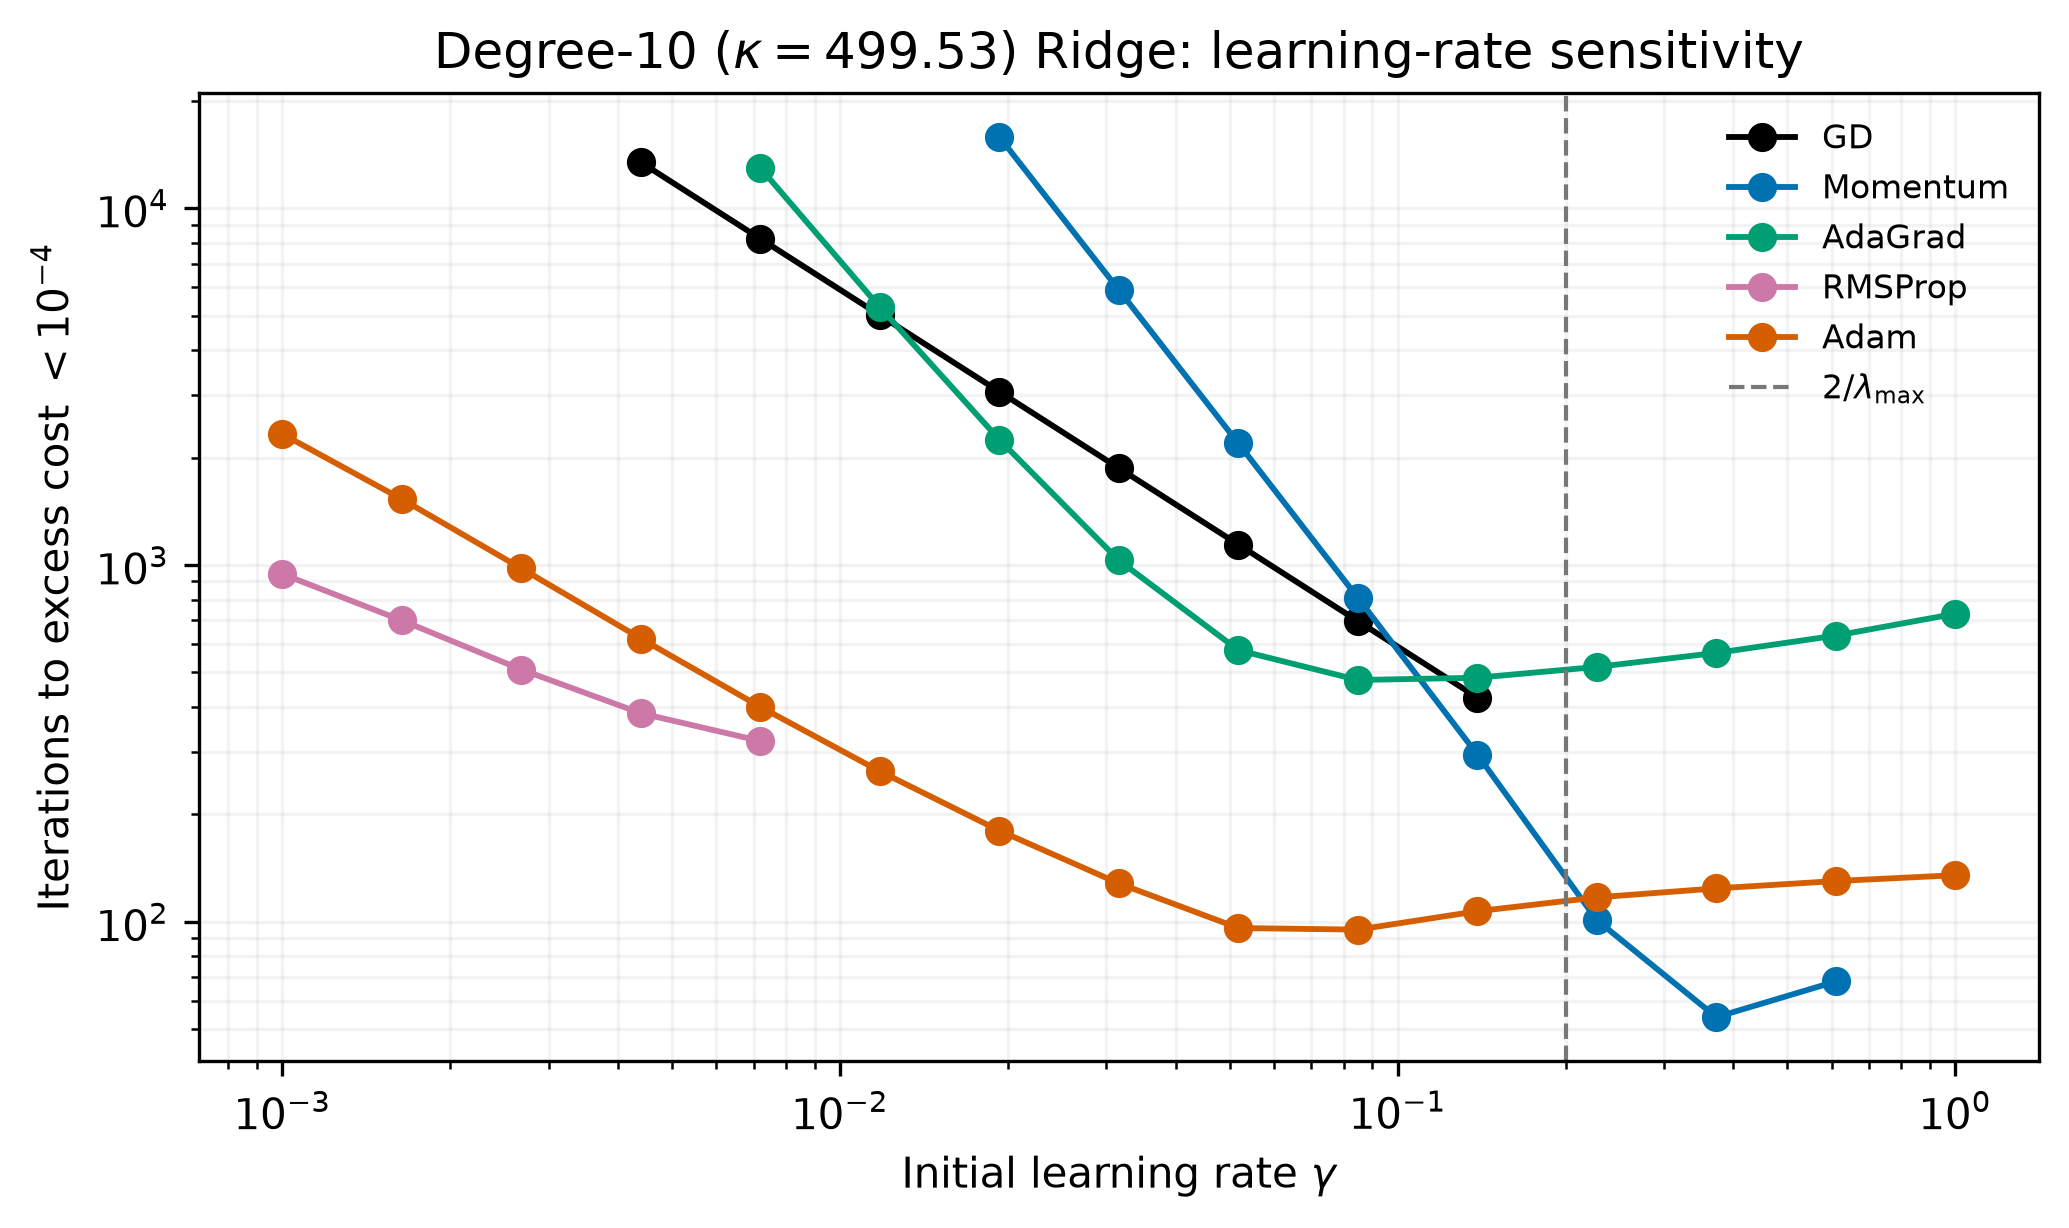

In [26]:
fig, ax = plt.subplots(figsize=(7.0, 4.2))

for i, method in enumerate(result_f_scan["methods"]):
    ax.loglog(
        result_f_scan["gammas"],
        result_f_scan["iterations"][i],
        "o-",
        color=colors[method],
        linewidth=1.4,
        label=method,
    )

ax.axvline(
    result_f_scan["gamma_max"],
    color=GREY,
    linestyle="--",
    linewidth=1,
    label=r"$2/\lambda_{\max}$",
)
ax.set_xlabel(r"Initial learning rate $\gamma$")
ax.set_ylabel(r"Iterations to excess cost $<10^{-4}$")
ax.set_title(
    rf"Degree-{OPTIMIZER_DEGREE} ($\kappa={result_f_scan['kappa']:.2f}$) "
    rf"Ridge: learning-rate sensitivity"
)
ax.grid(alpha=0.15, which="both")
ax.legend(frameon=False, fontsize=8)

fig.tight_layout()
path_f_scan = save_figure(
    fig,
    FIGURES_DIR,
    "part_f_learning_rate_sensitivity.pdf",
)
plt.show()


In [27]:
rows = []
for i, method in enumerate(result_f_scan["methods"]):
    valid = np.isfinite(result_f_scan["iterations"][i])
    if np.any(valid):
        j = np.nanargmin(result_f_scan["iterations"][i])
        rows.append(
            {
                "Method": method,
                "Best gamma": result_f_scan["gammas"][j],
                "Iterations": result_f_scan["iterations"][i, j],
            }
        )

table_f = pd.DataFrame(rows)
table_f

,Method,Best gamma,Iterations
0,GD,0.138950,425.0
1,Momentum,0.372759,54.0
2,AdaGrad,0.084834,476.0
3,RMSProp,0.007197,321.0
4,Adam,0.084834,95.0


In [28]:
save_latex_table(
    table_f,
    TABLES_DIR,
    "part_f_learning_rates.tex",
    "Best scanned learning rates among runs that reach the target parameter error.",
    "optimizer-learning-rates",
)

Saved: /home/hmmorad/school/STK/fys-stk3155/project1/report/tables/part_f_learning_rates.tex
Use in main.tex: \input{tables/part_f_learning_rates.tex}


PosixPath('/home/hmmorad/school/STK/fys-stk3155/project1/report/tables/part_f_learning_rates.tex')

# **Part g)**: Lasso regression

Lasso does not have a closed-form solution, so we solve it with the gradient-based methods from the previous parts and compare the result with scikit-learn.

In [29]:
import importlib
import project1.scripts.part_g

importlib.reload(project1.scripts.part_g)
from project1.scripts import part_g

result_g_compare = part_g.compare(x, y, degree=10, lam=0.01, max_iter=30000, tol=1e-8)

First, we check what happens to the gradient at $\theta=0$.

In [30]:
print("Gradient at theta=0:")
print("Analytical:", result_g_compare["gradient_zero"]["analytic"])
print("JAX:", result_g_compare["gradient_zero"]["jax"])
print("\nDifference (JAX vs Analytical):")
print(result_g_compare["gradient_zero"]["jax"] - result_g_compare["gradient_zero"]["analytic"])

Gradient at theta=0:
Analytical: [ 0.051895  0.44292   0.048029  0.345422  0.030922  0.295519  0.011522
  0.263654 -0.00643   0.240509]
JAX: [0.061895 0.45292  0.058029 0.355422 0.040922 0.305519 0.021522 0.273654
 0.00357  0.250509]

Difference (JAX vs Analytical):
[0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]


JAX returns $+1$ for the derivative of $|\theta|$ at $\theta=0$, while our analytical implementation uses `np.sign(0) = 0`. The difference is therefore $\lambda=0.01$. Both are valid subgradients at zero.

In [31]:
comparison_rows = []

for name, result in result_g_compare["results"].items():
    comparison_rows.append(
        {
            "Optimizer": name,
            "Iterations": result["n_iterations"],
            "Final cost": float(result["costs"][-1]),
            r"$\|\theta-\theta_{\mathrm{sklearn}}\|_2$": result["theta_difference"],
        }
    )

table_g = pd.DataFrame(comparison_rows)

table_g

,Optimizer,Iterations,Final cost,$\|\theta-\theta_{\mathrm{sklearn}}\|_2$
0,GD ($\gamma=0.01$),30000,0.045036,0.000864
1,Momentum ($\gamma=0.01$),30000,0.046079,0.312178
2,Adam ($\gamma=0.01$),30000,0.045107,0.004622


In [32]:
save_latex_table(
    table_g,
    TABLES_DIR,
    "part_g_optimizers.tex",
    "Lasso regression with some selected optimizers, compared with Sklearn's Lasso.",
    "lasso-optimizers",
)

Saved: /home/hmmorad/school/STK/fys-stk3155/project1/report/tables/part_g_optimizers.tex
Use in main.tex: \input{tables/part_g_optimizers.tex}


PosixPath('/home/hmmorad/school/STK/fys-stk3155/project1/report/tables/part_g_optimizers.tex')

In [33]:
list_selected_lambdas = list(SELECTED_LAMBDAS.values())

result_g = part_g.run(
    x, y, np.array(list_selected_lambdas), MAX_DEGREE, TEST_SIZE, SEED, 50000, 1e-8
)

We also compare the test MSE for a few values of $\lambda$.

Saved: /home/hmmorad/school/STK/fys-stk3155/project1/figures/part_g_lasso_selected_lambda.pdf


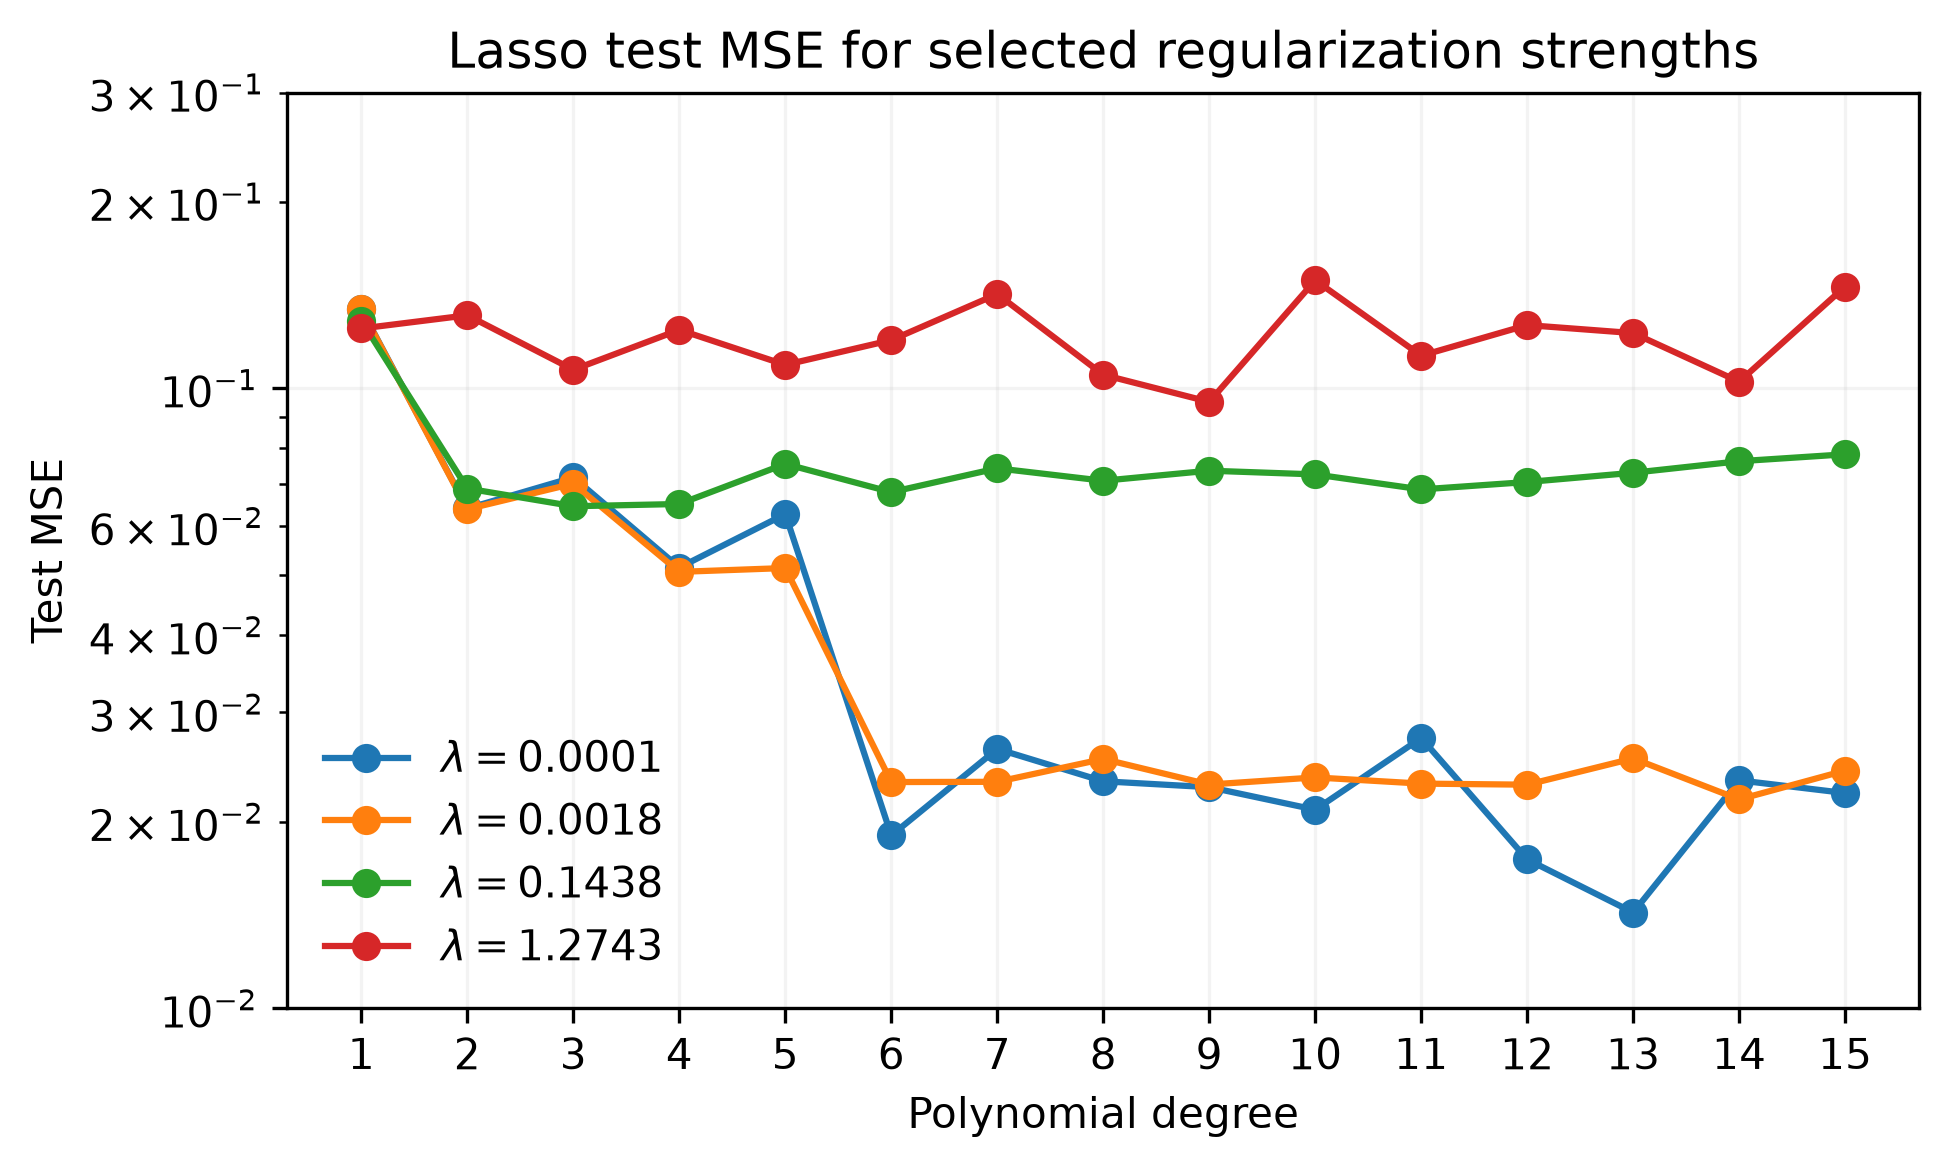

In [34]:
fig, ax = plt.subplots(figsize=(6.6, 4.0))

for i, lam in enumerate(list_selected_lambdas):
    ax.plot(result_g["degrees"], result_g["test_mse"][:, i], "o-", label=rf"$\lambda={lam:.4f}$")

    ax.set_title("Lasso test MSE for selected regularization strengths")
    ax.set_xlabel("Polynomial degree")
    ax.set_ylabel("Test MSE")
    ax.set_yscale("log")
    ax.set_xticks(result_g["degrees"])
    ax.legend(frameon=False)
    ax.set_ylim(bottom=1e-2, top=3e-1)
    ax.grid(alpha=0.15)

path_g_curves = save_figure(fig, FIGURES_DIR, "part_g_lasso_selected_lambda.pdf")
plt.show()

In [35]:
summary_rows = []
for degree in (2, 6, 8, 10, 12, 15):
    theta = result_g["theta"][degree - 1, :degree]

    summary_rows.append(
        {
            "Degree": degree,
            "Exact zeros": int(np.count_nonzero(theta == 0.0)),
            r"$|\theta| < 10^{-3}$": int(np.count_nonzero(np.abs(theta) < 1e-3)),
        }
    )

table_theta = pd.DataFrame(summary_rows).set_index("Degree")
table_theta

,Exact zeros,$|\theta| < 10^{-3}$
Degree,,
2,0,0
6,0,2
8,0,0
10,0,2
12,0,3
15,0,4


In [36]:
save_latex_table(
    table_theta,
    TABLES_DIR,
    "part_g_lasso_theta.tex",
    "Lasso coefficient estimates for selected polynomial degrees.",
    "lasso-theta",
)

Saved: /home/hmmorad/school/STK/fys-stk3155/project1/report/tables/part_g_lasso_theta.tex
Use in main.tex: \input{tables/part_g_lasso_theta.tex}


PosixPath('/home/hmmorad/school/STK/fys-stk3155/project1/report/tables/part_g_lasso_theta.tex')

# **Part h)**: Stochastic gradient descent

First, we look at the variation in minibatch gradients. Then we compare the full-batch gradient descent with a few implementations of SGD.

In [37]:
import importlib
import project1.scripts.part_h

importlib.reload(project1.scripts.part_h)
from project1.scripts import part_h

result_h_cloud = part_h.gradient_cloud(x, y, degree=2, batch_sizes=(5, 25), n_rounds=40, seed=SEED)

result_h_sgd = part_h.run_comparison(x, y, degree=OPTIMIZER_DEGREE, n_epochs=100, seed=SEED)


Saved: /home/hmmorad/school/STK/fys-stk3155/project1/figures/part_h_sgd.pdf


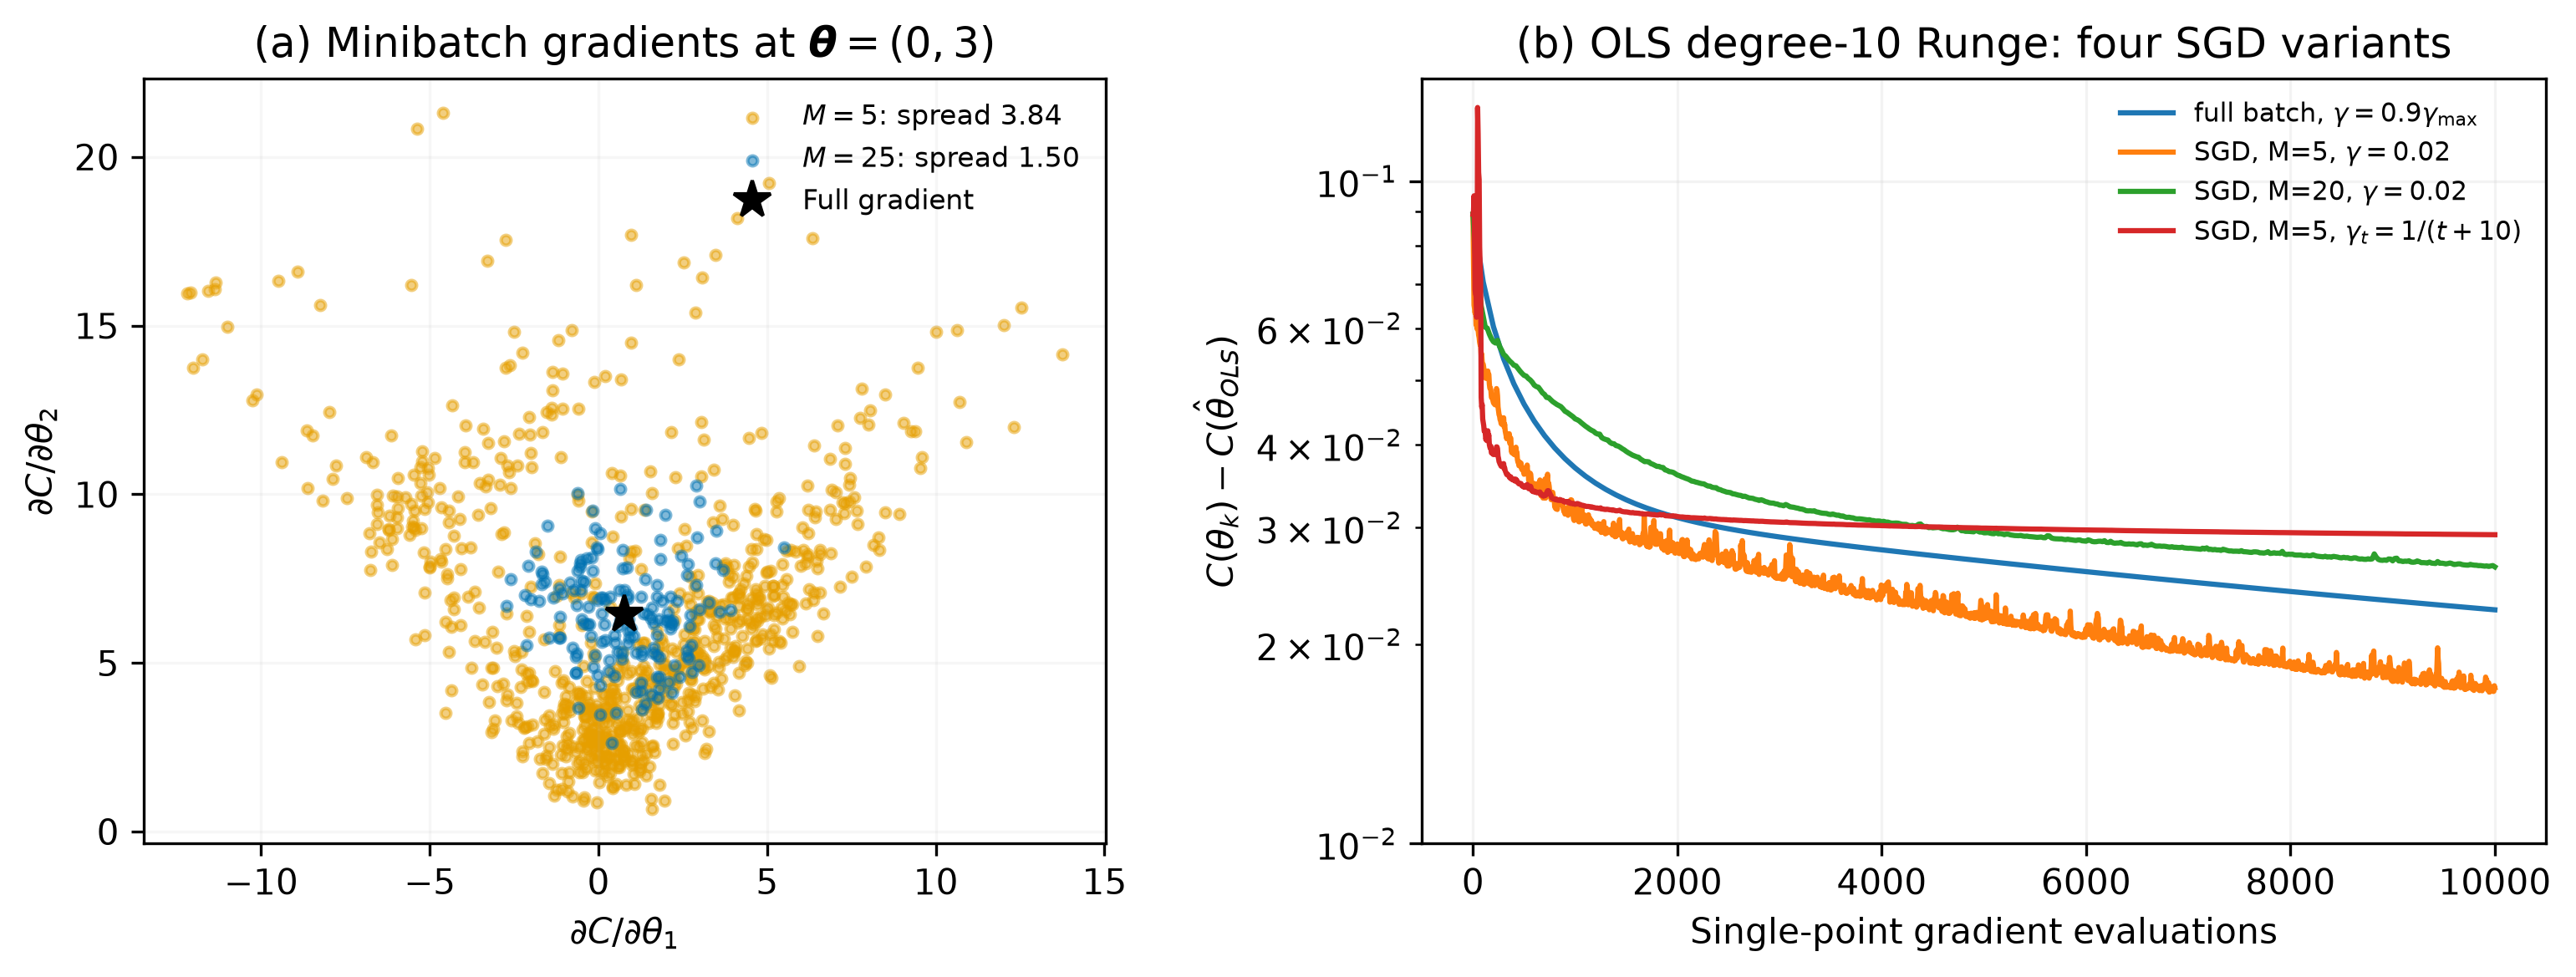

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))

# (a) Minibatch gradient cloud.
ax = axes[0]
full_gradient = result_h_cloud["full_gradient"]
gradients = result_h_cloud["gradients"]

for batch_size, color, label in ((5, YELLOW, "$M=5$"), (25, BLUE, "$M=25$")):
    values = gradients[batch_size]
    ax.scatter(
        values[:, 0],
        values[:, 1],
        s=8,
        color=color,
        alpha=0.5,
        label=rf"{label}: spread {np.std(values, axis=0).mean():.2f}",
    )

ax.plot(*full_gradient, "k*", markersize=11, label="Full gradient")
ax.set_xlabel(r"$\partial C/\partial\theta_1$")
ax.set_ylabel(r"$\partial C/\partial\theta_2$")
ax.set_title(r"(a) Minibatch gradients at $\boldsymbol{\theta}=(0,3)$")
ax.set_aspect("equal")
ax.grid(alpha=0.1)
ax.legend(frameon=False, fontsize=8)

# (b) Distance to the OLS closed-form solution.
ax = axes[1]
for label, values in result_h_sgd["results"].items():
    ax.semilogy(
        values["gradient_evaluations"],
        values["excess_cost"],
        linewidth=1.5,
        label=label,
    )

ax.set_xlabel("Single-point gradient evaluations")
ax.set_ylabel(r"$C(\boldsymbol{{\theta}}_k)-C(\hat{{\boldsymbol{{\theta}}}}_{{OLS}})$")
ax.set_title(f"(b) OLS degree-{OPTIMIZER_DEGREE} Runge: four SGD variants")
ax.grid(alpha=0.15)
ax.legend(frameon=False, fontsize=7.5, loc="best")
ax.set_ylim(bottom=1e-2)

fig.tight_layout()
path_h = save_figure(
    fig,
    FIGURES_DIR,
    "part_h_sgd.pdf",
)
plt.show()


# **Part i)**: Final OLS, Ridge and Lasso comparison

Cross-validation is used to choose the model. After that, the selected model is refitted using all training data and evaluated once on the untouched test set.

In [40]:
import importlib
import project1.scripts.part_i

importlib.reload(project1.scripts.part_i)
from project1.scripts import part_i

### NOTE: This part will run for a long time.
# You can change LAMBDAS below to a few selected ones to make the computation faster.
result_i = part_i.run(
    x, y, lambdas=LAMBDAS, max_degree=MAX_DEGREE, n_splits=5, test_size=TEST_SIZE, seed=SEED
)
### Took about 40 minutes with low-battery ASUS ZenBook 14, Ryzen 5 5625U, 16 GB RAM
### Reran it with many desktop applications open; got 74 minutes

print(result_i["best_models"])


{'OLS': {'degree': 10, 'lambda': nan, 'cv_mse': 0.023504653862329784, 'standard_error': 0.004849887615126194, 'test_mse': np.float64(0.03701856327153192), 'test_r2': np.float64(0.7016627642175595), 'theta': array([ -0.067172,  -3.032655,  -0.193237,  13.664027,   1.642167,
       -28.105326,  -2.750142,  26.612539,   1.370098,  -9.405014]), 'minimum_degree': 12}, 'Ridge': {'degree': 6, 'lambda': 0.0018329807108324356, 'cv_mse': 0.028945594922839886, 'standard_error': 0.004678203324661431, 'test_mse': np.float64(0.031743399544050796), 'test_r2': np.float64(0.744175969098387), 'theta': array([-0.067868, -0.888539,  0.100636,  1.075699, -0.053846, -0.393958]), 'minimum_degree': 8, 'minimum_lambda': 0.0001}, 'Lasso': {'degree': 6, 'lambda': 0.0018329807108324356, 'cv_mse': 0.02703876020687033, 'standard_error': 0.004995546219149918, 'test_mse': np.float64(0.02322986848126097), 'test_r2': np.float64(0.8127875817477062), 'theta': array([-0.041809, -1.058808,  0.020116,  1.501021,  0.002876, 

The CV curves below include the fold-to-fold standard error. The selected degree is marked on each curve.

Saved: /home/hmmorad/school/STK/fys-stk3155/project1/figures/part_i_final_cv_comparison.pdf


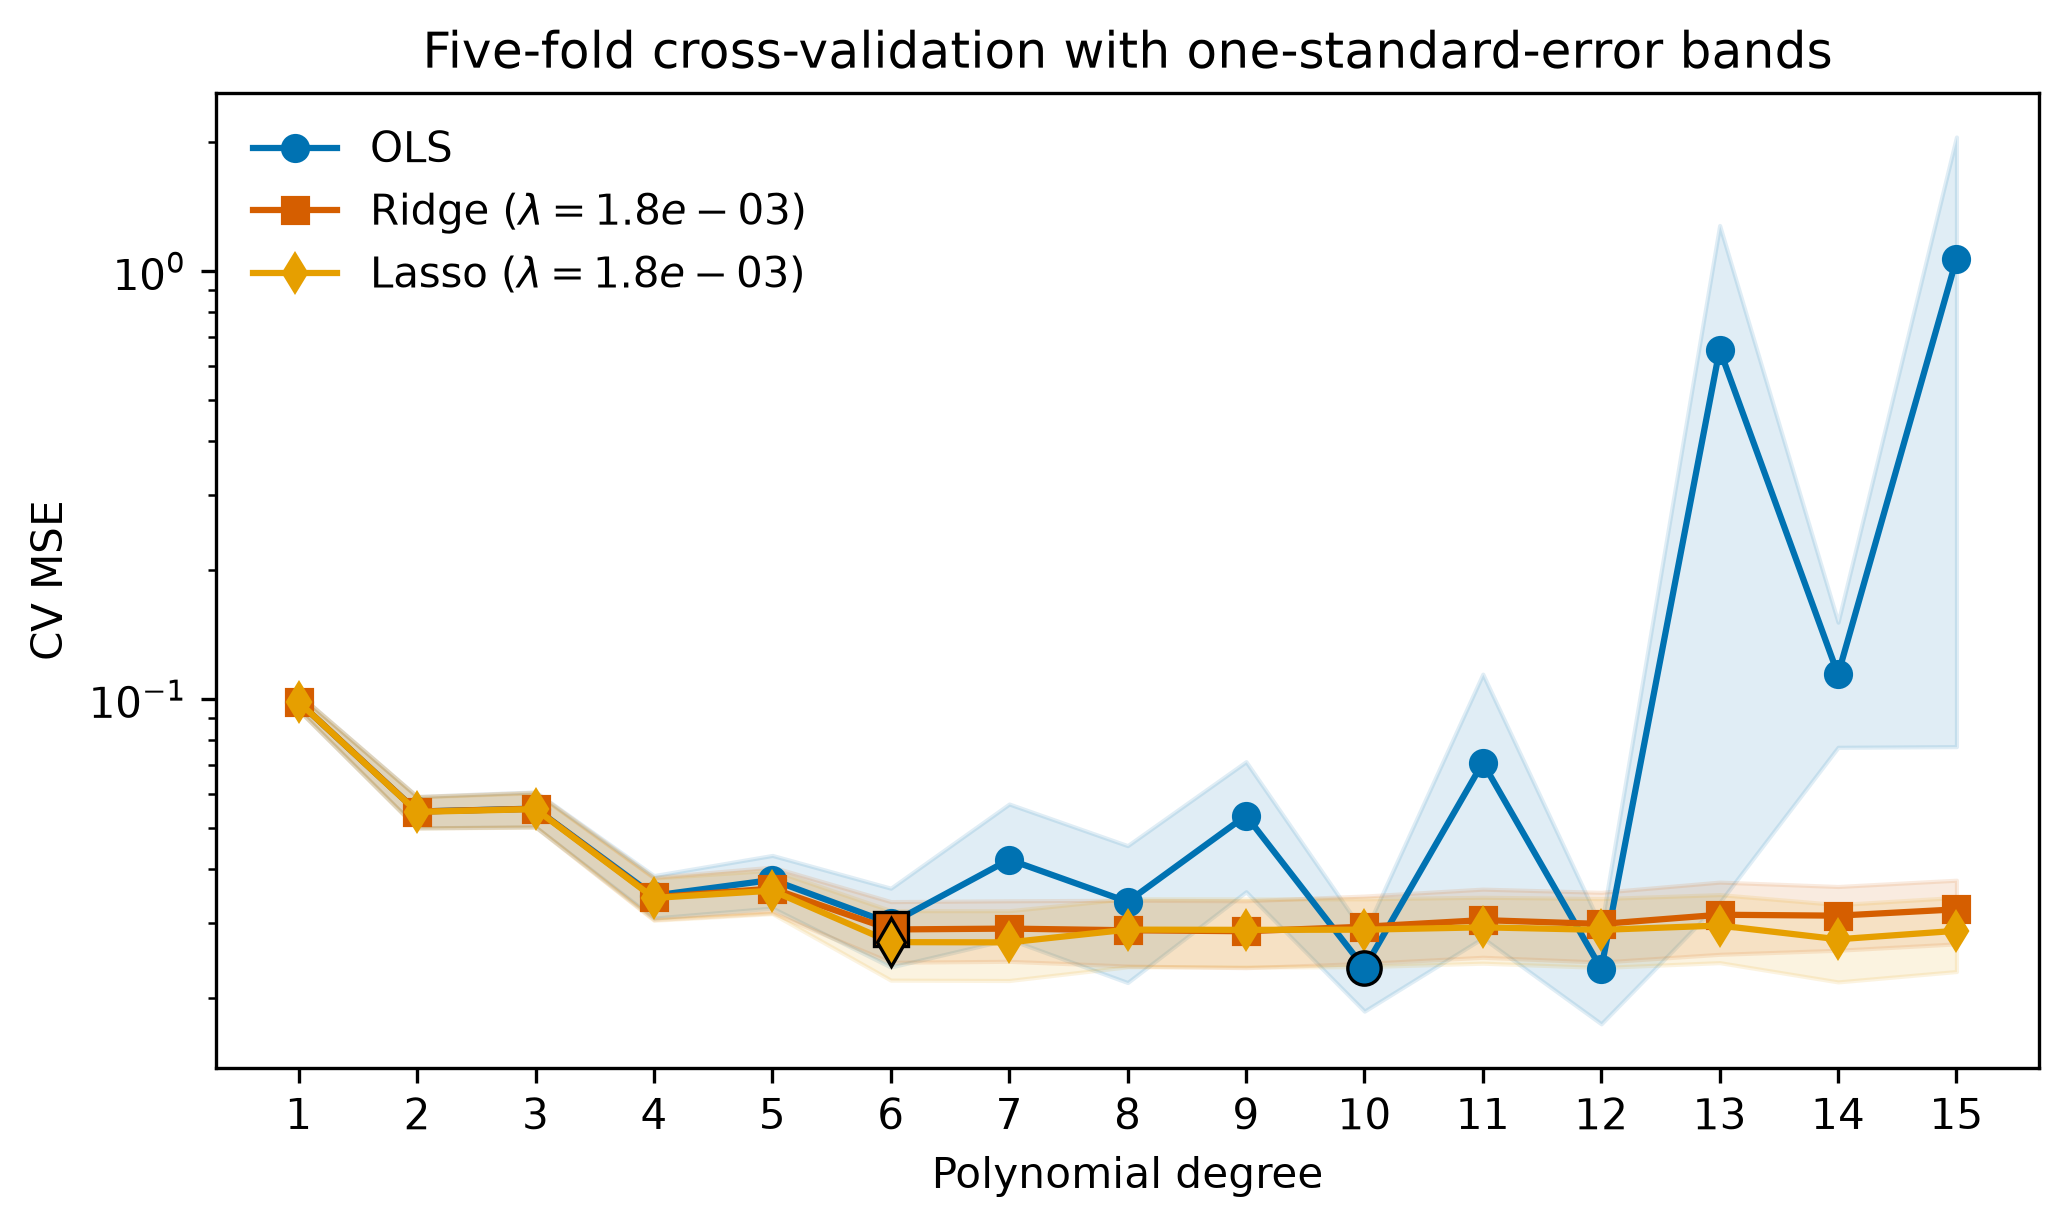

In [41]:
fig, ax = plt.subplots(figsize=(7.0, 4.2))

degrees = result_i["degrees"]
lambdas = result_i["lambdas"]

ols = result_i["ols_mse"]
ols_se = result_i["ols_se"]

ridge_best = result_i["best_models"]["Ridge"]
ridge_lambda_idx = int(np.argmin(np.abs(lambdas - ridge_best["lambda"])))
ridge = result_i["ridge_mse"][:, ridge_lambda_idx]
ridge_se = result_i["ridge_se"][:, ridge_lambda_idx]

lasso_best = result_i["best_models"]["Lasso"]
lasso_lambda_idx = int(np.argmin(np.abs(lambdas - lasso_best["lambda"])))
lasso = result_i["lasso_mse"][:, lasso_lambda_idx]
lasso_se = result_i["lasso_se"][:, lasso_lambda_idx]

ax.plot(degrees, ols, "o-", color=OLS_COLOR, label="OLS")
ax.fill_between(degrees, np.maximum(ols - ols_se, 1e-12), ols + ols_se, color=OLS_COLOR, alpha=0.12)

ax.plot(
    degrees, ridge, "s-", color=RIDGE_COLOR, label=rf"Ridge ($\lambda={ridge_best['lambda']:.1e}$)"
)
ax.fill_between(
    degrees, np.maximum(ridge - ridge_se, 1e-12), ridge + ridge_se, color=RIDGE_COLOR, alpha=0.12
)

ax.plot(
    degrees, lasso, "d-", color=LASSO_COLOR, label=rf"Lasso ($\lambda={lasso_best['lambda']:.1e}$)"
)
ax.fill_between(
    degrees, np.maximum(lasso - lasso_se, 1e-12), lasso + lasso_se, color=LASSO_COLOR, alpha=0.12
)

# Mark the degree chosen by the one-standard-error rule.
for name, color, marker in (
    ("OLS", OLS_COLOR, "o"),
    ("Ridge", RIDGE_COLOR, "s"),
    ("Lasso", LASSO_COLOR, "d"),
):
    best = result_i["best_models"][name]

    if name == "OLS":
        y_value = ols[best["degree"] - 1]
    elif name == "Ridge":
        y_value = ridge[best["degree"] - 1]
    else:
        y_value = lasso[best["degree"] - 1]

    ax.plot(
        best["degree"],
        y_value,
        marker=marker,
        color=color,
        markersize=8,
        markeredgecolor="black",
        markeredgewidth=0.8,
    )

ax.set_title("Five-fold cross-validation with one-standard-error bands")
ax.set_xlabel("Polynomial degree")
ax.set_ylabel("CV MSE")
ax.set_yscale("log")
ax.set_xticks(degrees)
ax.legend(frameon=False)

path_i = save_figure(fig, FIGURES_DIR, "part_i_final_cv_comparison.pdf")

plt.show()

The final table contains the selected model, its CV error and standard error, and the final test-set performance.

In [42]:
rows = []

for name, result in result_i["best_models"].items():
    rows.append(
        {
            "Model": name,
            "Degree": result["degree"],
            "Lambda": ("-" if np.isnan(result["lambda"]) else f"{result['lambda']:.1e}"),
            "CV MSE": result["cv_mse"],
            "CV SE": result["standard_error"],
            "Test MSE": result["test_mse"],
            "Test R2": result["test_r2"],
        }
    )

final_table = pd.DataFrame(rows)
final_table

,Model,Degree,Lambda,CV MSE,CV SE,Test MSE,Test R2
0,OLS,10,-,0.023505,0.004850,0.037019,0.701663
1,Ridge,6,1.8e-03,0.028946,0.004678,0.031743,0.744176
2,Lasso,6,1.8e-03,0.027039,0.004996,0.023230,0.812788


In [43]:
path_i_table = save_latex_table(
    final_table,
    TABLES_DIR,
    "part_i_final_models.tex",
    "Final OLS, Ridge and Lasso models selected using five-fold cross-validation.",
    "final-models",
)

Saved: /home/hmmorad/school/STK/fys-stk3155/project1/report/tables/part_i_final_models.tex
Use in main.tex: \input{tables/part_i_final_models.tex}


In [ ]:
for name, result in result_i["best_models"].items():
    theta = np.asarray(result["theta"])

    print(f"\n{name}")
    print(f"Degree: {result['degree']}")

    if not np.isnan(result["lambda"]):
        print(f"Lambda: {result['lambda']:.6g}")

    print("theta:")
    print(np.array2string(theta, precision=6, suppress_small=True))

    if name == "Lasso":
        exact_zeros = np.count_nonzero(theta == 0.0)
        near_zeros = np.count_nonzero(np.isclose(theta, 0.0, atol=1e-6))

        print(f"Exact zeros: {exact_zeros}")
        print(f"|theta| < 1e-6: {near_zeros}")


OLS
Degree: 10
theta:
[ -0.067172  -3.032655  -0.193237  13.664027   1.642167 -28.105326
  -2.750142  26.612539   1.370098  -9.405014]

Ridge
Degree: 6
Lambda: 0.00183298
theta:
[-0.067868 -0.888539  0.100636  1.075699 -0.053846 -0.393958]

Lasso
Degree: 6
Lambda: 0.00183298
theta:
[-0.041809 -1.058808  0.020116  1.501021  0.002876 -0.657229]
Exact zeros: 0
|theta| < 1e-6: 0


## Done

The figures have been saved to `figures/` and the LaTeX tables to `report/tables/`.